# 🏙️ Chicago Crime Dataset — Comprehensive Exploratory Data Analysis

---

## Executive Summary

> **Objective:** Conduct a rigorous Exploratory Data Analysis of the Chicago Crime dataset to understand patterns in crime type, location, temporal distribution, arrest outcomes, and other relevant variables. All findings are derived directly from the data — no fabricated results.

### Key Highlights *(populated after analysis)*:
- **Dataset Size:** ~120,759 records × 23 columns
- **Time Period:** Determined after loading
- **Most Common Crime Types:** Identified through analysis
- **Overall Arrest Rate:** Calculated from data
- **Temporal Patterns:** Peak hours, months, and seasonal effects
- **Geographic Patterns:** Spatial crime distribution
- **Data Quality:** Missing values, duplicates, anomalies

---

### Table of Contents

1. Introduction & Libraries
2. Load Dataset
3. Data Overview
4. Data Quality Assessment
5. Data Cleaning & Feature Engineering
6. Univariate Analysis
7. Bivariate Analysis
8. Multivariate Analysis
9. Geographic Analysis
10. Correlation Analysis
11. Statistical Analysis
12. Key Insights
13. Conclusion

## 1. Import Libraries

In [95]:
import os
import glob
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

# Global plot configuration
plt.rcParams.update({
    'figure.figsize': (12, 6),
    'figure.dpi': 100,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.titlesize': 16,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

# Color palette
PALETTE = sns.color_palette("husl", 15)
ACCENT = '#2196F3'
ACCENT2 = '#FF5722'
SEQUENTIAL_CMAP = 'YlOrRd'

### Helper Functions

Reusable utility functions for plotting and analysis throughout the notebook.

In [96]:
def plot_top_categories(series, n=15, title='', xlabel='Count', ylabel='',
                        color=ACCENT, figsize=(12, 7), horizontal=True):
    """Plot top N categories from a pandas Series."""
    top = series.value_counts().head(n)
    fig, ax = plt.subplots(figsize=figsize)
    if horizontal:
        top.sort_values().plot(kind='barh', ax=ax, color=color)
        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)
        for i, v in enumerate(top.sort_values()):
            ax.text(v + top.max() * 0.01, i, f'{v:,}', va='center', fontsize=9)
    else:
        top.plot(kind='bar', ax=ax, color=color, edgecolor='white')
        ax.set_ylabel(xlabel)
        ax.set_xlabel(ylabel)
        plt.xticks(rotation=45, ha='right')
    ax.set_title(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()


def plot_percentage_bar(labels, values, title='', xlabel='', color=ACCENT, figsize=(12, 7)):
    """Plot horizontal bar chart with percentage annotations."""
    fig, ax = plt.subplots(figsize=figsize)
    y_pos = range(len(labels))
    ax.barh(y_pos, values, color=color, edgecolor='white')
    ax.set_yticks(y_pos)
    ax.set_yticklabels(labels)
    ax.set_xlabel(xlabel)
    ax.set_title(title, fontsize=14, fontweight='bold')
    for i, v in enumerate(values):
        ax.text(v + max(values) * 0.01, i, f'{v:.1f}%', va='center', fontsize=9)
    plt.tight_layout()
    plt.show()

def calculate_percentage(series):
    """Calculate value counts and percentages."""
    counts = series.value_counts()
    percentages = (counts / counts.sum() * 100).round(2)
    return pd.DataFrame({'Count': counts, 'Percentage (%)': percentages})

## 2. Load Dataset

We load the Chicago Crime dataset from the local CSV file. The dataset was downloaded from the Google Drive link provided. If you need to re-download, place the file in this directory as `chicago_crime_data.csv`.

The loading logic auto-detects the dataset file by scanning for CSV files in the project directory.

In [97]:
url="https://drive.google.com/file/d/1Efog2t2MWgm1Ciyn2nZyXqR9YAhUm7Ur/view?usp=sharing"
url='https://drive.google.com/uc?id=' + url.split('/')[-2] #stack overflow
df = pd.read_csv(url)

df=df.drop(columns="_year")

## 3. Data Overview

We begin by inspecting the dataset's structure: shape, columns, data types, memory usage, and summary statistics.

In [98]:
# 3.1 First 5 rows
print("  FIRST 5 ROWS")
df.head()

  FIRST 5 ROWS


,ID,Case Number,Date,Block,IUCR,Primary Type,Description,Location Description,Arrest,Domestic,...,Ward,Community Area,FBI Code,X Coordinate,Y Coordinate,Year,Updated On,Latitude,Longitude,Location
0,13733090,JJ130321,01/28/2025 03:30:00 PM,076XX S RACINE AVE,0560,ASSAULT,SIMPLE,STREET,False,False,...,17.0,71.0,08A,1169643.0,1854247.0,2025,05/17/2025 03:40:52 PM,41.755554,-87.653868,"(41.755554244, -87.653867946)"
1,13909076,JJ344224,07/22/2025 12:40:00 PM,011XX W THORNDALE AVE,0560,ASSAULT,SIMPLE,TAVERN / LIQUOR STORE,True,False,...,48.0,77.0,08A,1167566.0,1939682.0,2025,03/14/2026 03:41:39 PM,41.990039,-87.659020,"(41.990039445, -87.659019968)"
2,13101860,JG295014,06/09/2023 08:23:00 PM,008XX S KOLMAR AVE,1507,PROSTITUTION,SOLICIT OFF PUBLIC WAY,STREET,True,False,...,24.0,26.0,16,1146144.0,1895827.0,2023,08/19/2023 03:40:26 PM,41.870133,-87.738933,"(41.870133029, -87.738933006)"
3,13701134,JH553823,12/24/2024 05:38:00 AM,043XX N KIMBALL AVE,0910,MOTOR VEHICLE THEFT,AUTOMOBILE,CONVENIENCE STORE,False,False,...,33.0,16.0,07,1152935.0,1928827.0,2024,11/02/2025 03:41:09 PM,41.960556,-87.713125,"(41.96055619, -87.71312483)"
4,13967696,JJ415709,09/15/2025 03:20:00 PM,004XX S WESTERN AVE,0312,ROBBERY,ARMED - KNIFE / CUTTING INSTRUMENT,CTA TRAIN,True,False,...,28.0,28.0,03,1160478.0,1897788.0,2025,03/14/2026 03:41:39 PM,41.875230,-87.686254,"(41.875229772, -87.686253982)"


In [99]:
# 3.2 Last 5 rows
print("  LAST 5 ROWS")
df.tail()

  LAST 5 ROWS


,ID,Case Number,Date,Block,IUCR,Primary Type,Description,Location Description,Arrest,Domestic,...,Ward,Community Area,FBI Code,X Coordinate,Y Coordinate,Year,Updated On,Latitude,Longitude,Location
120754,12816225,JF383003,09/04/2022 12:00:00 AM,044XX S ALBANY AVE,1365,CRIMINAL TRESPASS,TO RESIDENCE,RESIDENCE,False,False,...,14.0,58.0,26,1156440.0,1875105.0,2022,01/03/2023 03:40:27 PM,41.813068,-87.701692,"(41.813067574, -87.701692471)"
120755,13643877,JH484130,10/26/2024 06:00:00 PM,030XX W 71ST ST,0560,ASSAULT,SIMPLE,APARTMENT,False,True,...,18.0,66.0,08A,1157400.0,1857393.0,2024,05/17/2025 03:40:52 PM,41.764444,-87.698651,"(41.764443935, -87.698650734)"
120756,13912639,JJ348512,07/25/2025 01:37:00 PM,065XX W DEVON AVE,1320,CRIMINAL DAMAGE,TO VEHICLE,STREET,False,False,...,45.0,10.0,14,1131902.0,1942088.0,2025,03/14/2026 03:41:39 PM,41.997337,-87.790145,"(41.997337332, -87.790144642)"
120757,13893174,JJ325121,07/07/2025 08:50:00 PM,020XX W 52ND ST,0460,BATTERY,SIMPLE,STREET,True,False,...,16.0,61.0,08B,1163588.0,1870007.0,2025,03/14/2026 03:41:39 PM,41.798931,-87.675616,"(41.798930883, -87.67561635)"
120758,12829854,JF399261,09/17/2022 03:28:00 AM,072XX S HALSTED ST,0430,BATTERY,AGGRAVATED - OTHER DANGEROUS WEAPON,STREET,True,False,...,6.0,68.0,04B,1172220.0,1856860.0,2022,01/03/2023 03:40:27 PM,41.762668,-87.644347,"(41.762668404, -87.644347199)"


In [100]:
# 3.3 Random sample
print("  RANDOM SAMPLE (5 rows)")
df.sample(5, random_state=42)

  RANDOM SAMPLE (5 rows)


,ID,Case Number,Date,Block,IUCR,Primary Type,Description,Location Description,Arrest,Domestic,...,Ward,Community Area,FBI Code,X Coordinate,Y Coordinate,Year,Updated On,Latitude,Longitude,Location
59995,13401629,JH191926,03/18/2024 04:44:00 AM,007XX N HAMLIN AVE,1365,CRIMINAL TRESPASS,TO RESIDENCE,APARTMENT,True,False,...,27.0,23.0,26,1150923.0,1904674.0,2024,12/21/2024 03:40:46 PM,41.894318,-87.721156,"(41.894318003, -87.721155977)"
8309,12285691,JE132130,02/04/2021 10:27:00 AM,005XX N TRUMBULL AVE,1477,WEAPONS VIOLATION,RECKLESS FIREARM DISCHARGE,STREET,False,False,...,27.0,23.0,15,1153278.0,1903640.0,2021,02/11/2021 03:40:22 PM,41.891434,-87.712534,"(41.891434171, -87.712534202)"
11256,12870979,JF448605,10/25/2022 11:15:00 AM,035XX W CONGRESS PKWY,2024,NARCOTICS,POSSESS - HEROIN (WHITE),ALLEY,True,False,...,28.0,27.0,18,1152905.0,1897466.0,2022,01/03/2023 03:40:27 PM,41.874499,-87.714068,"(41.874499471, -87.714067682)"
62131,12892755,JF474452,11/14/2022 02:14:00 PM,022XX W 24TH ST,1310,CRIMINAL DAMAGE,TO PROPERTY,APARTMENT,False,False,...,25.0,31.0,14,1161580.0,1888036.0,2022,01/03/2023 03:40:27 PM,41.848446,-87.682479,"(41.848446468, -87.682479316)"
9959,12283170,JE129053,02/01/2021 10:38:00 AM,049XX W HUBBARD ST,1822,NARCOTICS,MANUFACTURE / DELIVER - CANNABIS OVER 10 GRAMS,SIDEWALK,True,False,...,37.0,25.0,18,1143291.0,1902558.0,2021,02/08/2021 03:40:33 PM,41.888657,-87.749239,"(41.888657457, -87.7492392)"


In [101]:
# 3.4 Dataset dimensions and column names
print(f"Number of rows:    {df.shape[0]:,}")
print(f"Number of columns: {df.shape[1]}")
print(f"\nColumn Names:")
for i, col in enumerate(df.columns, 1):
    print(f"  {i:2d}. {col}")

Number of rows:    120,759
Number of columns: 22

Column Names:
   1. ID
   2. Case Number
   3. Date
   4. Block
   5. IUCR
   6. Primary Type
   7. Description
   8. Location Description
   9. Arrest
  10. Domestic
  11. Beat
  12. District
  13. Ward
  14. Community Area
  15. FBI Code
  16. X Coordinate
  17. Y Coordinate
  18. Year
  19. Updated On
  20. Latitude
  21. Longitude
  22. Location


In [102]:
# 3.5 Data types and inf0
print("DATA TYPES & INFO\n")
df.info()

DATA TYPES & INFO

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120759 entries, 0 to 120758
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   ID                    120759 non-null  int64  
 1   Case Number           120759 non-null  object 
 2   Date                  120759 non-null  object 
 3   Block                 120759 non-null  object 
 4   IUCR                  120759 non-null  object 
 5   Primary Type          120759 non-null  object 
 6   Description           120759 non-null  object 
 7   Location Description  120296 non-null  object 
 8   Arrest                120759 non-null  bool   
 9   Domestic              120759 non-null  bool   
 10  Beat                  120759 non-null  int64  
 11  District              120759 non-null  int64  
 12  Ward                  120759 non-null  float64
 13  Community Area        120748 non-null  float64
 14  FBI Code              120759 non-

In [103]:
# 3.7 Numerical summary statistics
print("  NUMERICAL SUMMARY STATISTICS")
df.describe()

  NUMERICAL SUMMARY STATISTICS


,ID,Beat,District,Ward,Community Area,X Coordinate,Y Coordinate,Year,Latitude,Longitude
count,1.207590e+05,120759.000000,120759.000000,120759.000000,120748.000000,1.188820e+05,1.188820e+05,120759.000000,118882.000000,118882.000000
mean,1.313421e+07,1151.098634,11.281039,23.322262,36.457730,1.165042e+06,1.887090e+06,2023.092432,41.845761,-87.669844
std,9.600914e+05,704.389546,7.038287,13.848473,21.456534,1.640964e+04,3.146721e+04,1.382963,0.086536,0.059751
min,2.570300e+04,111.000000,1.000000,1.000000,1.000000,1.091242e+06,1.813914e+06,2021.000000,41.644604,-87.939733
25%,1.272905e+07,533.000000,5.000000,10.000000,23.000000,1.153358e+06,1.859960e+06,2022.000000,41.771113,-87.712334
50%,1.318890e+07,1033.000000,10.000000,24.000000,32.000000,1.167053e+06,1.894048e+06,2023.000000,41.865016,-87.662582
75%,1.363746e+07,1723.000000,17.000000,34.000000,53.000000,1.176659e+06,1.909520e+06,2024.000000,41.907369,-87.627271
max,1.428388e+07,2535.000000,31.000000,50.000000,77.000000,1.205114e+06,1.951499e+06,2025.000000,42.022537,-87.524616


In [104]:
# 3.8 Categorical summary statistics
print("  CATEGORICAL SUMMARY STATISTICS")
df.describe(include='object')

  CATEGORICAL SUMMARY STATISTICS


,Case Number,Date,Block,IUCR,Primary Type,Description,Location Description,FBI Code,Updated On,Location
count,120759,120759,120759,120759,120759,120759,120296,120759,120759,118882
unique,120755,104269,24042,326,31,304,129,26,2494,73766
top,JJ261204,01/01/2021 12:00:00 AM,001XX N STATE ST,0486,THEFT,SIMPLE,STREET,06,01/03/2023 03:40:27 PM,"(41.883500187, -87.627876698)"
freq,2,21,480,10297,23660,13338,33558,23996,21737,267


### Observations from Data Overview

- The dataset contains **crime incident records** from Chicago with fields for crime type, location, arrest status, and geographic coordinates.
- **Key Identifiers:** `ID`, `Case Number`
- **Target/Outcome Variables:** `Arrest` (boolean), `Domestic` (boolean)
- **Temporal Variables:** `Date`, `Year`, `_year` (appears to be a duplicate year column)
- **Geographic Variables:** `Latitude`, `Longitude`, `X Coordinate`, `Y Coordinate`, `Location`, `Block`
- **Categorical Variables:** `Primary Type`, `Description`, `Location Description`, `FBI Code`, `IUCR`
- **Numerical Variables:** `Beat`, `District`, `Ward`, `Community Area`

## 3.1 Data Understanding — Variable Classification

Let's systematically classify all columns into numerical, categorical, and temporal variables.

In [105]:
# Classify variables
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
boolean_cols = df.select_dtypes(include=['bool']).columns.tolist()

print(f"Numerical Variables ({len(numerical_cols)}):")
for c in numerical_cols:
    n_unique = df[c].nunique()
    print(f"  • {c:25s} | unique: {n_unique:,} | range: [{df[c].min()}, {df[c].max()}]")

print(f"\nCategorical Variables ({len(categorical_cols)}):")
for c in categorical_cols:
    n_unique = df[c].nunique()
    print(f"  • {c:25s} | unique: {n_unique:,}")

print(f"\nBoolean Variables ({len(boolean_cols)}):")
for c in boolean_cols:
    print(f"  • {c:25s} | True: {df[c].sum():,} | False: {(~df[c]).sum():,}")

Numerical Variables (10):
  • ID                        | unique: 120,759 | range: [25703, 14283883]
  • Beat                      | unique: 275 | range: [111, 2535]
  • District                  | unique: 23 | range: [1, 31]
  • Ward                      | unique: 50 | range: [1.0, 50.0]
  • Community Area            | unique: 77 | range: [1.0, 77.0]
  • X Coordinate              | unique: 40,048 | range: [1091242.0, 1205114.0]
  • Y Coordinate              | unique: 50,709 | range: [1813914.0, 1951499.0]
  • Year                      | unique: 5 | range: [2021, 2025]
  • Latitude                  | unique: 73,761 | range: [41.644604096, 42.022537168]
  • Longitude                 | unique: 73,750 | range: [-87.939732936, -87.524616331]

Categorical Variables (10):
  • Case Number               | unique: 120,755
  • Date                      | unique: 104,269
  • Block                     | unique: 24,042
  • IUCR                      | unique: 326
  • Primary Type              | uniq

## 4. Data Cleaning & Feature Engineering

### 4.1 Parse Date Column

Convert the `Date` column to datetime and extract useful temporal features.

In [106]:
# Parse date column
df['Date'] = pd.to_datetime(df['Date'], errors='coerce', infer_datetime_format=True)

midnight_mask = (df['Date'].dt.time == pd.Timestamp('00:00:00').time())
n_midnight = midnight_mask.sum()
df = df[~midnight_mask].copy()

# Extract temporal features
df['Month'] = df['Date'].dt.month
df['Month_Name'] = df['Date'].dt.month_name()
df['Day'] = df['Date'].dt.day
df['Day_of_Week'] = df['Date'].dt.day_name()
df['Day_of_Week_Num'] = df['Date'].dt.dayofweek   # 0=Monday, 6=Sunday
df['Hour'] = df['Date'].dt.hour
df['Quarter'] = df['Date'].dt.quarter
df['Is_Weekend'] = df['Date'].dt.dayofweek.isin([5, 6]).astype(int)

print(f"Date parsed and temporal features extracted.")
print(f"Date range: {df['Date'].min()} → {df['Date'].max()}")
print(f"Years covered: {df['Year'].min()} – {df['Year'].max()}")
print(f"Records with invalid dates: {df['Date'].isna().sum():,}")
print(f"New columns added: Month, Month_Name, Day, Day_of_Week, Day_of_Week_Num, Hour, Quarter, Is_Weekend")

/tmp/ipykernel_1728/4161039035.py:2: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  df['Date'] = pd.to_datetime(df['Date'], errors='coerce', infer_datetime_format=True)
/tmp/ipykernel_1728/4161039035.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date'] = pd.to_datetime(df['Date'], errors='coerce', infer_datetime_format=True)


Date parsed and temporal features extracted.
Date range: 2021-01-01 00:01:00 → 2025-12-31 23:58:00
Years covered: 2021 – 2025
Records with invalid dates: 0
New columns added: Month, Month_Name, Day, Day_of_Week, Day_of_Week_Num, Hour, Quarter, Is_Weekend


## 5. Data Quality Assessment

A thorough data-quality audit covering missing values, duplicates, inconsistencies, and numerical anomalies.

### 5.1 Missing Values

Columns with missing values: 7 out of 30
                      Missing Count  Missing %
Y Coordinate                   1626       1.39
Location                       1626       1.39
Latitude                       1626       1.39
Longitude                      1626       1.39
X Coordinate                   1626       1.39
Location Description            442       0.38
Community Area                   11       0.01


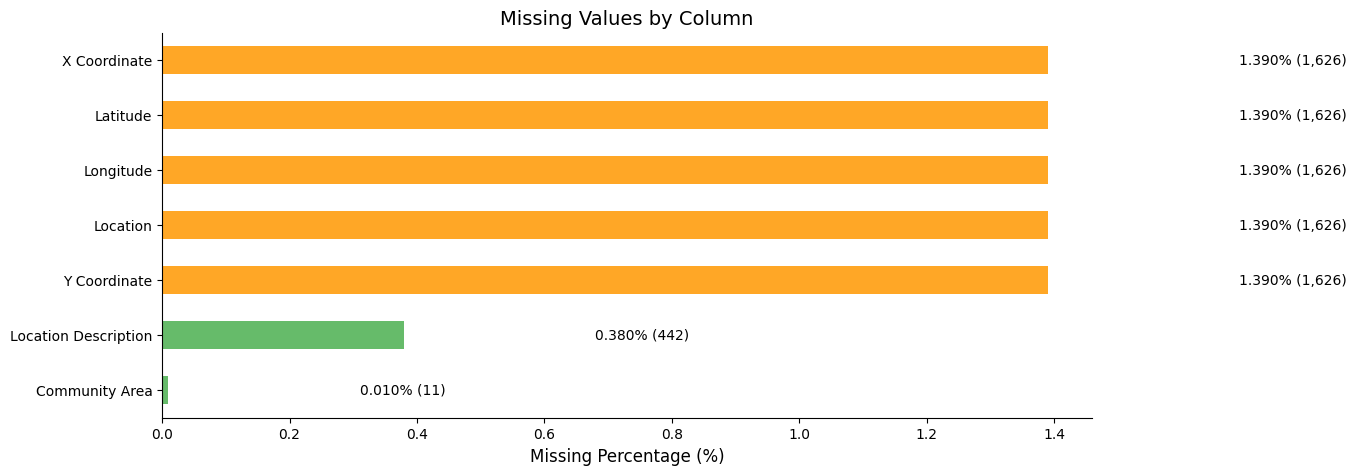

In [107]:
# Calculate missing values
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
}).sort_values('Missing %', ascending=False)

# Show only columns with missing values
missing_with = missing_df[missing_df['Missing Count'] > 0]
print(f"Columns with missing values: {len(missing_with)} out of {len(df.columns)}")
print(missing_with.to_string())

# Visualize missing values
if len(missing_with) > 0:
    fig, ax = plt.subplots(figsize=(12, max(5, len(missing_with) * 0.5)))

    colors = ['#E53935' if p > 10 else '#FFA726' if p > 1 else '#66BB6A'
              for p in missing_with['Missing %']]

    missing_with['Missing %'].sort_values().plot(
        kind='barh', ax=ax, color=colors[::-1])
    ax.set_xlabel('Missing Percentage (%)')
    ax.set_title('Missing Values by Column')

    for i, (idx, row) in enumerate(missing_with.sort_values('Missing %').iterrows()):
        ax.text(row['Missing %'] + 0.3, i,
                f"{row['Missing %']:.3f}% ({int(row['Missing Count']):,})",
                va='center')

    plt.show()
else:
    print("✅ No missing values found in the dataset!")

**Interpretation of Missing Values:**

- Columns like `Location`, `Latitude`, `Longitude`, `X Coordinate`, `Y Coordinate` may have missing geographic data — these are expected for incidents where location couldn't be geocoded.
- `Ward` and `Community Area` missingness typically correlates with missing geographic data.
- We will **not** drop rows with missing values blindly. Instead, we handle them contextually in each analysis section.

---

### 5.2 Duplicate Records

In [108]:
# Check for exact duplicates
n_dupes = df.duplicated().sum()
pct_dupes = n_dupes / len(df) * 100

print(f"Completely duplicated rows: {n_dupes:,} ({pct_dupes:.2f}%)")
print(f"Unique rows:               {len(df) - n_dupes:,}")

# Check duplicate IDs
n_unique_ids = df['ID'].nunique()
print(f"\nUnique IDs:      {n_unique_ids:,} / {len(df):,}")
if n_unique_ids < len(df):
    print(f"→ {len(df) - n_unique_ids:,} records share an ID with another record.")

# Check duplicate Case Numbers
n_unique_cases = df['Case Number'].nunique()
print(f"Unique Case Nos: {n_unique_cases:,} / {len(df):,}")

Completely duplicated rows: 0 (0.00%)
Unique rows:               116,687

Unique IDs:      116,687 / 116,687
Unique Case Nos: 116,683 / 116,687


### 5.3 Numerical Anomalies

Check for impossible values, particularly in latitude/longitude (Chicago bounds: lat ~41.6–42.1, lon ~-87.95 to -87.5).

In [109]:
# Check latitude/longitude bounds
print("GEOGRAPHIC COORDINATE VALIDATION")

# Chicago approximate bounds
CHI_LAT_MIN, CHI_LAT_MAX = 41.6, 42.1
CHI_LON_MIN, CHI_LON_MAX = -87.95, -87.5

if 'Latitude' in df.columns:
    lat = df['Latitude'].dropna()
    out_lat = lat[(lat < CHI_LAT_MIN) | (lat > CHI_LAT_MAX)]
    zero_lat = lat[lat == 0]
    print(f"\nLatitude:")
    print(f"  Valid records:     {len(lat):,}")
    print(f"  Range:             [{lat.min():.6f}, {lat.max():.6f}]")
    print(f"  Outside Chicago:   {len(out_lat):,} ({len(out_lat)/len(lat)*100:.2f}%)")
    print(f"  Zero values:       {len(zero_lat):,}")

if 'Longitude' in df.columns:
    lon = df['Longitude'].dropna()
    out_lon = lon[(lon < CHI_LON_MIN) | (lon > CHI_LON_MAX)]
    zero_lon = lon[lon == 0]
    print(f"\nLongitude:")
    print(f"  Valid records:     {len(lon):,}")
    print(f"  Range:             [{lon.min():.6f}, {lon.max():.6f}]")
    print(f"  Outside Chicago:   {len(out_lon):,} ({len(out_lon)/len(lon)*100:.2f}%)")
    print(f"  Zero values:       {len(zero_lon):,}")

# District, Ward, Beat ranges
for col in ['District', 'Ward', 'Community Area', 'Beat']:
    if col in df.columns:
        vals = df[col].dropna()
        print(f"\n{col}: range [{vals.min()}, {vals.max()}], unique: {vals.nunique()}")

GEOGRAPHIC COORDINATE VALIDATION

Latitude:
  Valid records:     115,061
  Range:             [41.644604, 42.022537]
  Outside Chicago:   0 (0.00%)
  Zero values:       0

Longitude:
  Valid records:     115,061
  Range:             [-87.939733, -87.524616]
  Outside Chicago:   0 (0.00%)
  Zero values:       0

District: range [1, 31], unique: 23

Ward: range [1.0, 50.0], unique: 50

Community Area: range [1.0, 77.0], unique: 77

Beat: range [111, 2535], unique: 275


## 6. Univariate Analysis

### 6.1 Crime Type Distribution

Analyze the distribution of crime types using the `Primary Type` column.

Total unique crime types: 31

Crime Types:
  THEFT                                22,867  ( 19.6%)
  BATTERY                              21,939  ( 18.8%)
  CRIMINAL DAMAGE                      10,914  ( 9.35%)
  ASSAULT                              10,164  ( 8.71%)
  OTHER OFFENSE                         7,870  ( 6.74%)
  MOTOR VEHICLE THEFT                   7,788  ( 6.67%)
  WEAPONS VIOLATION                     7,325  ( 6.28%)
  NARCOTICS                             6,828  ( 5.85%)
  DECEPTIVE PRACTICE                    6,120  ( 5.24%)
  ROBBERY                               3,834  ( 3.29%)
  BURGLARY                              3,309  ( 2.84%)
  CRIMINAL TRESPASS                     2,814  ( 2.41%)
  INTERFERENCE WITH PUBLIC OFFICER        664  (0.569%)
  OFFENSE INVOLVING CHILDREN              645  (0.553%)
  PUBLIC PEACE VIOLATION                  625  (0.536%)
  CRIMINAL SEXUAL ASSAULT                 619  ( 0.53%)
  SEX OFFENSE                             538  (0.461%)
  HOM

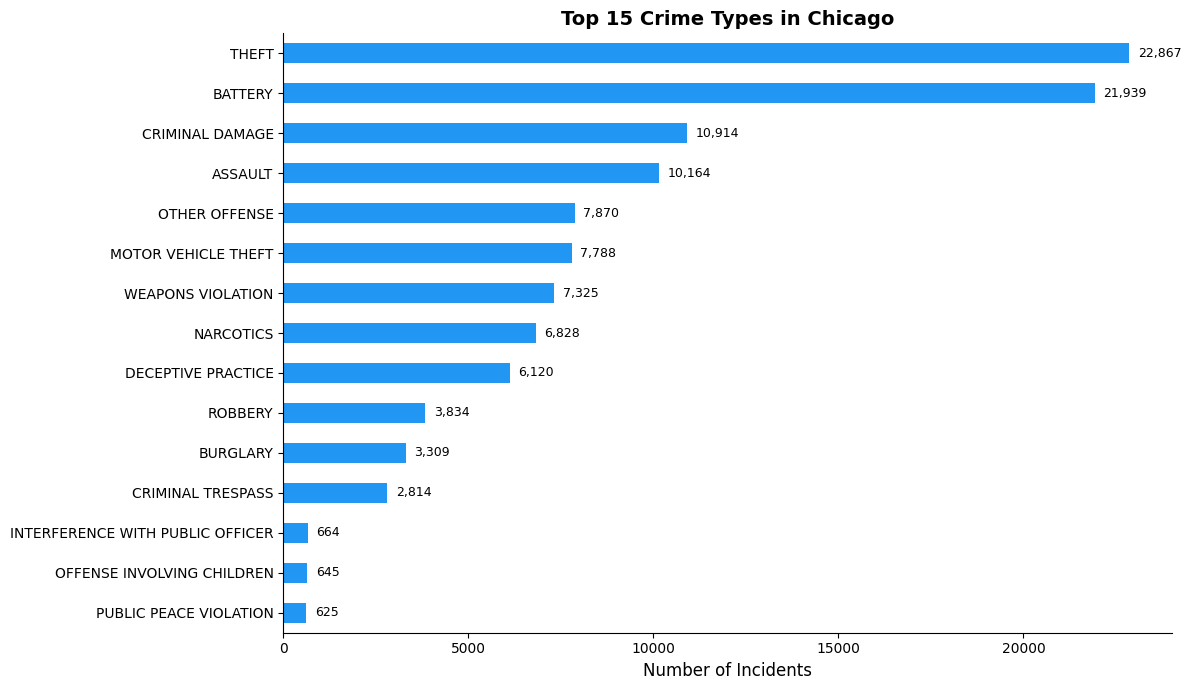

In [110]:
# Crime type analysis
crime_counts = df['Primary Type'].value_counts()
print(f"Total unique crime types: {len(crime_counts)}")
print(f"\nCrime Types:")
for crime, count in crime_counts.items():
    pct = count / len(df) * 100
    print(f"  {crime:35s} {count:>7,}  ({pct:5.3}%)")

# Visualization: Top 15 Crime Types
plot_top_categories(
    df['Primary Type'], n=15,
    title='Top 15 Crime Types in Chicago',
    xlabel='Number of Incidents'
)

### 6.2 Crime Description Distribution

The `Description` field provides more granular detail about each crime incident.

Total unique descriptions: 302

Top 15 Descriptions:
  SIMPLE                                         13,094  (11.221%)
  DOMESTIC BATTERY SIMPLE                        10,093  (8.650%)
  $500 AND UNDER                                  6,876  (5.893%)
  OVER $500                                       6,594  (5.651%)
  RETAIL THEFT                                    6,161  (5.280%)
  AUTOMOBILE                                      5,904  (5.060%)
  UNLAWFUL POSSESSION - HANDGUN                   5,890  (5.048%)
  TO VEHICLE                                      5,876  (5.036%)
  TO PROPERTY                                     4,881  (4.183%)
  AGGRAVATED - HANDGUN                            3,010  (2.580%)
  FROM BUILDING                                   1,838  (1.575%)
  FORCIBLE ENTRY                                  1,712  (1.467%)
  TO LAND                                         1,708  (1.464%)
  ARMED - HANDGUN                                 1,452  (1.244%)
  POSSESS - HEROIN (WH

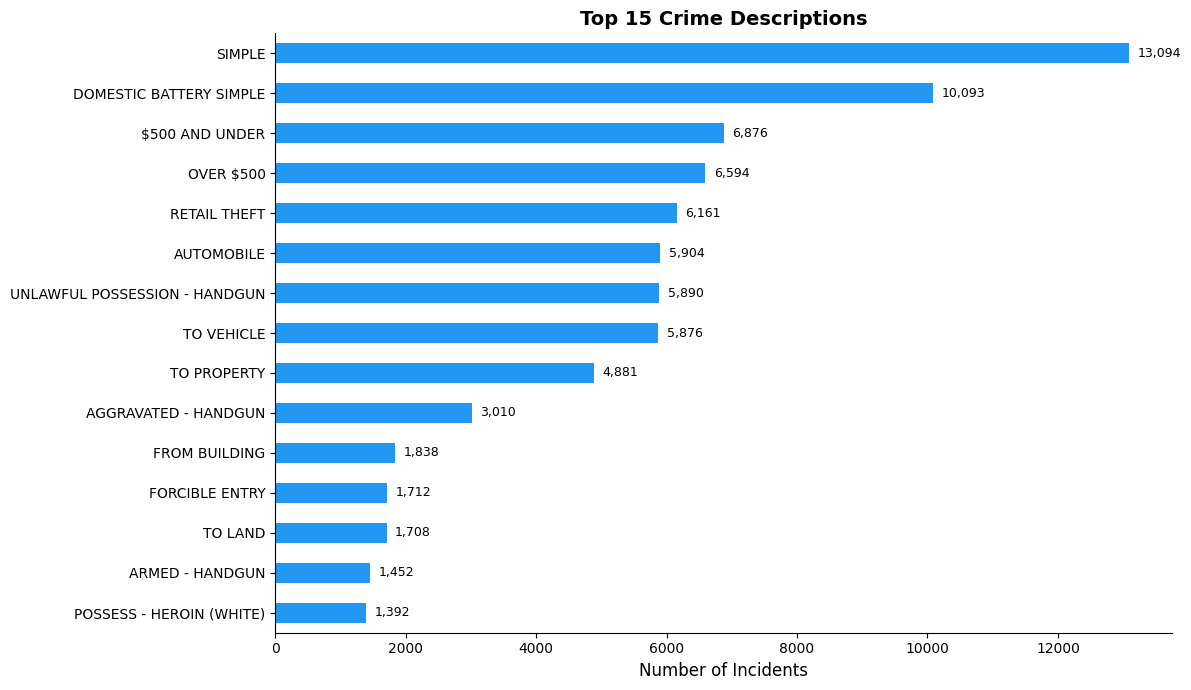

In [111]:
# Crime description analysis
print(f"Total unique descriptions: {df['Description'].nunique()}")
print(f"\nTop 15 Descriptions:")
for desc, count in df['Description'].value_counts().head(15).items():
    pct = count / len(df) * 100
    print(f"  {desc:45s} {count:>7,}  ({pct:5.3f}%)")

    # Visualization: Top 15 Crime Descriptions
plot_top_categories(
    df['Description'], n=15,
    title='Top 15 Crime Descriptions',
    xlabel='Number of Incidents'
)

### 6.3 Arrest Distribution

Analyze the overall arrest rate — what proportion of crimes result in an arrest?

        Count  Percentage (%)
Arrest                       
False   77610           66.51
True    39077           33.49

Overall Arrest Rate: 33.5%
   Arrests made:     39,077
   No arrest:        77,610


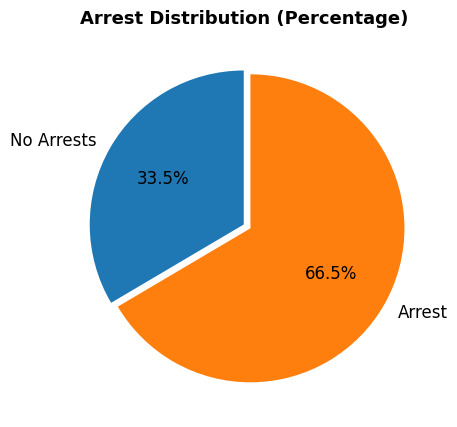

In [112]:
# Arrest analysis
arrest_dist = calculate_percentage(df['Arrest'])
print(arrest_dist)

overall_arrest_rate = df['Arrest'].mean() * 100
print(f"\nOverall Arrest Rate: {overall_arrest_rate:.1f}%")
print(f"   Arrests made:     {df['Arrest'].sum():,}")
print(f"   No arrest:        {(~df['Arrest']).sum():,}")

# Visualization: Arrest Distribution
fig, ax = plt.subplots(figsize=(5, 5))

# Pie chart (only 2 categories — appropriate use)
values=[df['Arrest'].sum(), (~df['Arrest']).sum()]
labels=['No Arrests', 'Arrest']
ax.pie(values, labels=labels, autopct='%1.1f%%', startangle=90, textprops={'fontsize': 12},
        explode=(0, 0.05))
ax.set_title('Arrest Distribution (Percentage)', fontsize=13, fontweight='bold')
plt.show()

### 6.4 Domestic Crimes

Analyze the proportion of crimes classified as domestic incidents.

          Count  Percentage (%)
Domestic                       
False     94080           80.63
True      22607           19.37

🏠 Domestic Crime Rate: 19.4%
   Domestic incidents:     22,607
   Non-domestic incidents: 94,080


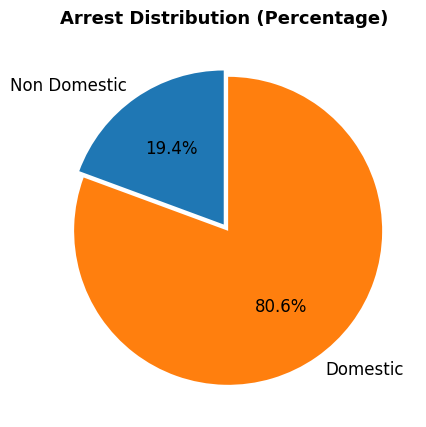

In [113]:
# Domestic crime analysis
domestic_dist = calculate_percentage(df['Domestic'])
print(domestic_dist)

domestic_rate = df['Domestic'].mean() * 100
print(f"\n🏠 Domestic Crime Rate: {domestic_rate:.1f}%")
print(f"   Domestic incidents:     {df['Domestic'].sum():,}")
print(f"   Non-domestic incidents: {(~df['Domestic']).sum():,}")

# Visualization: Arrest Distribution
fig, ax = plt.subplots(figsize=(5, 5))

# Pie chart (only 2 categories — appropriate use)
values=[df['Domestic'].sum(), (~df['Domestic']).sum()]
labels=['Non Domestic', 'Domestic']
ax.pie(values, labels=labels, autopct='%1.1f%%', startangle=90, textprops={'fontsize': 12},
        explode=(0, 0.05))
ax.set_title('Arrest Distribution (Percentage)', fontsize=13, fontweight='bold')
plt.show()

### 6.5 Location Distribution

Where do crimes occur most frequently?

Unique location types: 129

Top 15 Crime Locations:
  STREET                                    32,640  ( 28.0%)
  APARTMENT                                 20,901  ( 17.9%)
  RESIDENCE                                 13,072  ( 11.2%)
  SIDEWALK                                   7,701  (  6.6%)
  SMALL RETAIL STORE                         3,993  (  3.4%)
  PARKING LOT / GARAGE (NON RESIDENTIAL)     3,802  (  3.3%)
  ALLEY                                      3,057  (  2.6%)
  DEPARTMENT STORE                           2,676  (  2.3%)
  RESTAURANT                                 2,318  (  2.0%)
  VEHICLE NON-COMMERCIAL                     1,775  (  1.5%)
  GAS STATION                                1,649  (  1.4%)
  COMMERCIAL / BUSINESS OFFICE               1,543  (  1.3%)
  OTHER (SPECIFY)                            1,488  (  1.3%)
  RESIDENCE - PORCH / HALLWAY                1,412  (  1.2%)
  GROCERY FOOD STORE                         1,386  (  1.2%)


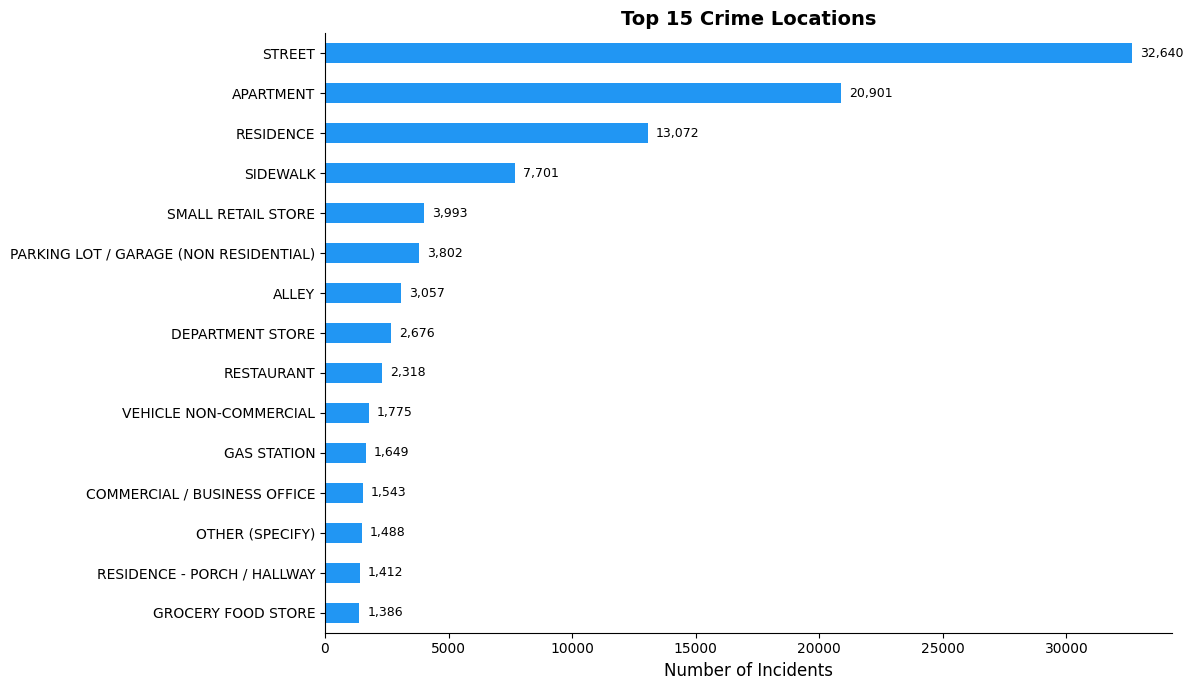

In [114]:
# Location description analysis
print(f"Unique location types: {df['Location Description'].nunique()}")
print(f"\nTop 15 Crime Locations:")
for loc, count in df['Location Description'].value_counts().head(15).items():
    pct = count / len(df) * 100
    print(f"  {str(loc):40s} {count:>7,}  ({pct:5.1f}%)")

# Visualization: Top 15 Crime Locations
plot_top_categories(
    df['Location Description'], n=15,
    title='Top 15 Crime Locations',
    xlabel='Number of Incidents'
)


Crimes by District (Top 10):
  District  11:   8,014  (  6.9%)
  District   8:   7,259  (  6.2%)
  District   6:   6,927  (  5.9%)
  District   1:   6,717  (  5.8%)
  District  12:   6,374  (  5.5%)
  District   4:   6,256  (  5.4%)
  District  25:   6,140  (  5.3%)
  District  18:   6,075  (  5.2%)
  District   3:   5,766  (  4.9%)
  District  19:   5,567  (  4.8%)


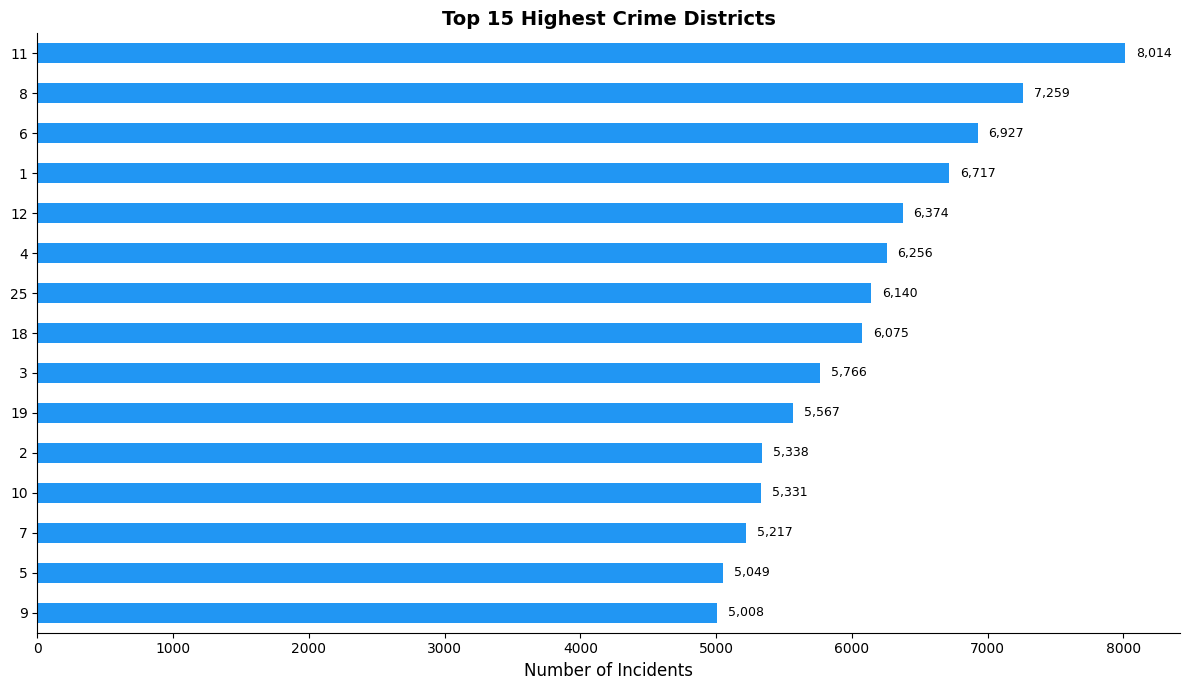

In [115]:
# District distribution
print(f"\nCrimes by District (Top 10):")
dist_counts = df['District'].value_counts().head(10)
for dist, count in dist_counts.items():
    pct = count / len(df) * 100
    print(f"  District {int(dist):3d}: {count:>7,}  ({pct:5.1f}%)")

# Visualization: Top 15 Crime Locations
plot_top_categories(
    df['District'], n=15,
    title='Top 15 Highest Crime Districts',
    xlabel='Number of Incidents'
)

### 6.6 Temporal Distribution

Analyze how crime varies across years, months, days of the week, and hours of the day.

Crimes by Year:
  2021:  20,127
  2022:  22,194
  2023:  24,803
  2024:  25,472
  2025:  24,091


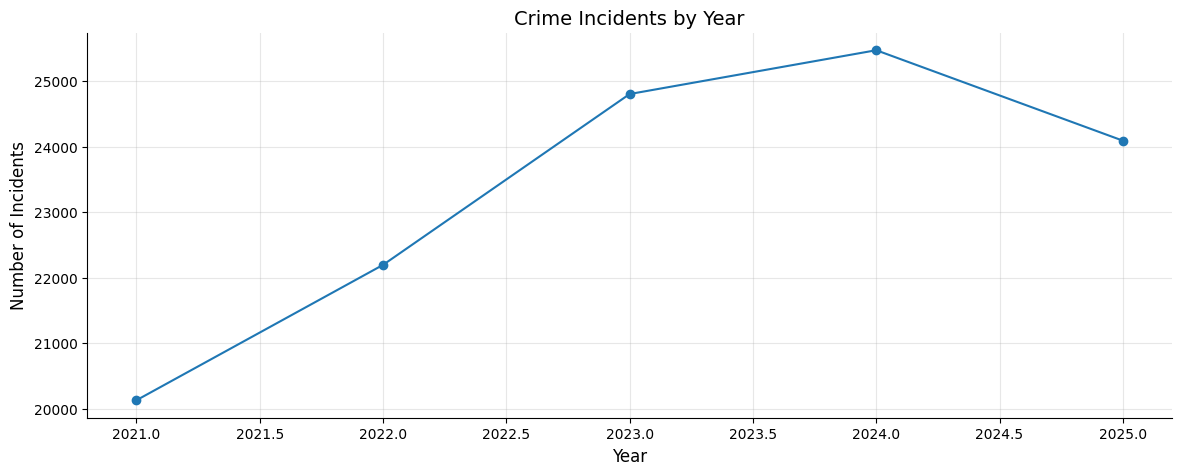

In [116]:
# 6.6.1 Crimes by Year
year_counts = df['Year'].value_counts().sort_index()
print("Crimes by Year:")
for year, count in year_counts.items():
    print(f"  {int(year)}: {count:>7,}")

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(year_counts.index, year_counts.values, marker='o')
ax.set_title('Crime Incidents by Year')
ax.set_xlabel('Year')
ax.set_ylabel('Number of Incidents')
ax.grid(axis='y', alpha=0.3)
ax.grid(axis='x', alpha=0.3)
plt.show()

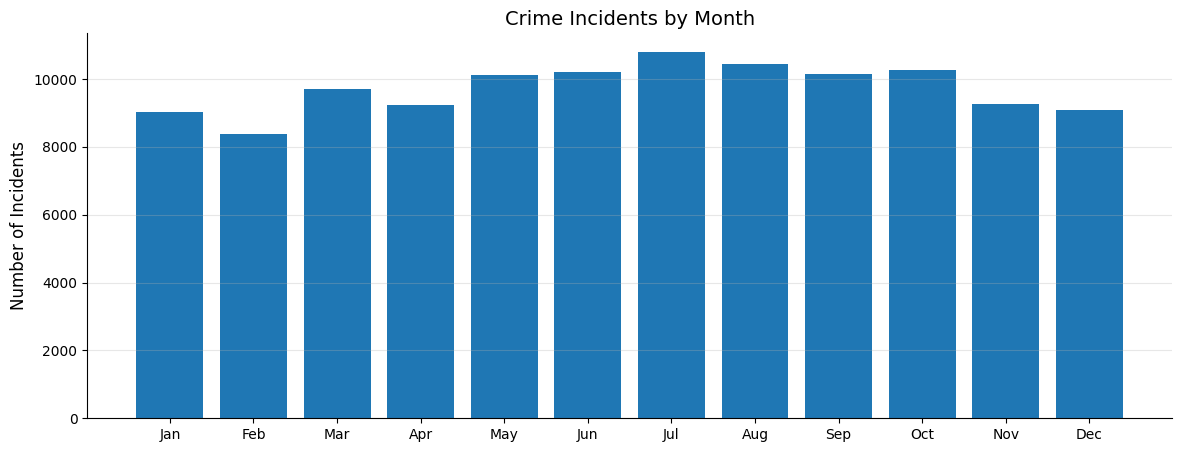

In [117]:
# 6.6.2 Crimes by Month
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']
month_counts = df['Month_Name'].value_counts().reindex(month_order)

fig, ax = plt.subplots(figsize=(14, 5))
bars = ax.bar(range(len(month_counts)), month_counts.values)
ax.set_xticks(range(12))
ax.set_xticklabels([m[:3] for m in month_order])
ax.set_title('Crime Incidents by Month')
ax.set_ylabel('Number of Incidents')
ax.grid(axis='y', alpha=0.3)
plt.show()

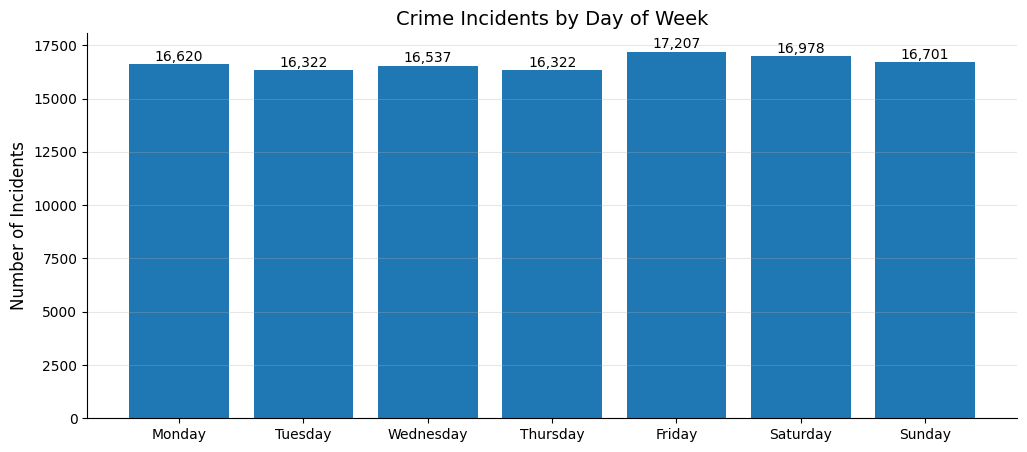

In [118]:
# 6.6.3 Crimes by Day of Week
dow_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dow_counts = df['Day_of_Week'].value_counts().reindex(dow_order)

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(dow_order, dow_counts.values)
ax.set_title('Crime Incidents by Day of Week')
ax.set_ylabel('Number of Incidents')
for i, v in enumerate(dow_counts.values):
    ax.text(i, v + dow_counts.max() * 0.01, f'{v:,}', ha='center')
ax.grid(axis='y', alpha=0.3)
plt.show()

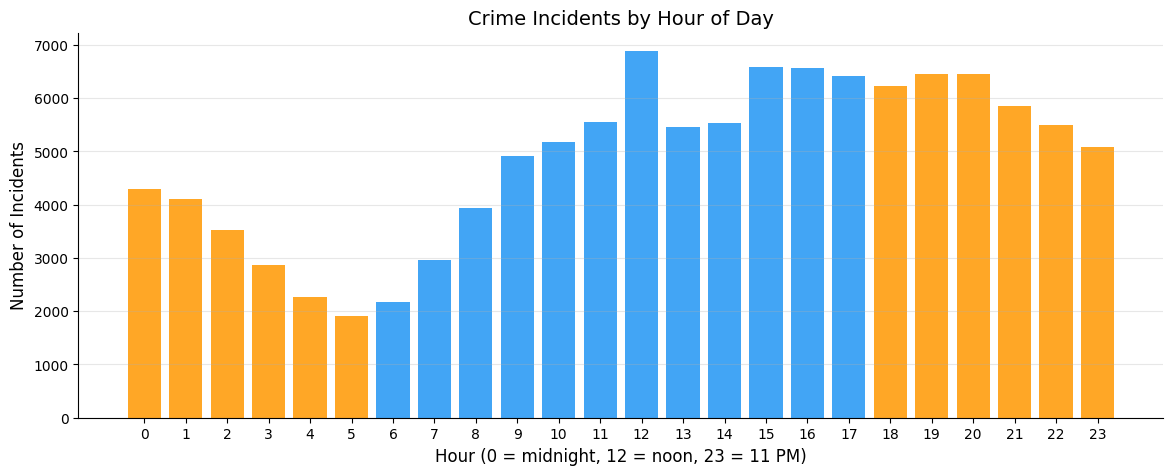

Highest crime hour: 12:00 (6,885 incidents)
Lowest crime hour: 5:00 (1,911 incidents)


In [119]:
# 6.6.4 Crimes by Hour of Day
hour_counts = df['Hour'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(14, 5))
colors_hour = ['#FFA726' if (h >= 18 or h <= 5) else '#42A5F5' for h in range(24)]
ax.bar(hour_counts.index, hour_counts.values, color=colors_hour)
ax.set_title('Crime Incidents by Hour of Day')
ax.set_xlabel('Hour (0 = midnight, 12 = noon, 23 = 11 PM)')
ax.set_ylabel('Number of Incidents')
ax.set_xticks(range(24))

ax.grid(axis='y', alpha=0.3)
plt.show()

print(f"Highest crime hour: {hour_counts.idxmax()}:00 ({hour_counts.max():,} incidents)")
print(f"Lowest crime hour: {hour_counts.idxmin()}:00 ({hour_counts.min():,} incidents)")

## 7. Bivariate Analysis

Investigating relationships between pairs of important variables.

### 7.1 Crime Type vs Arrest Rate

Not just raw arrest counts — we calculate the **arrest rate** (percentage) for each crime type.

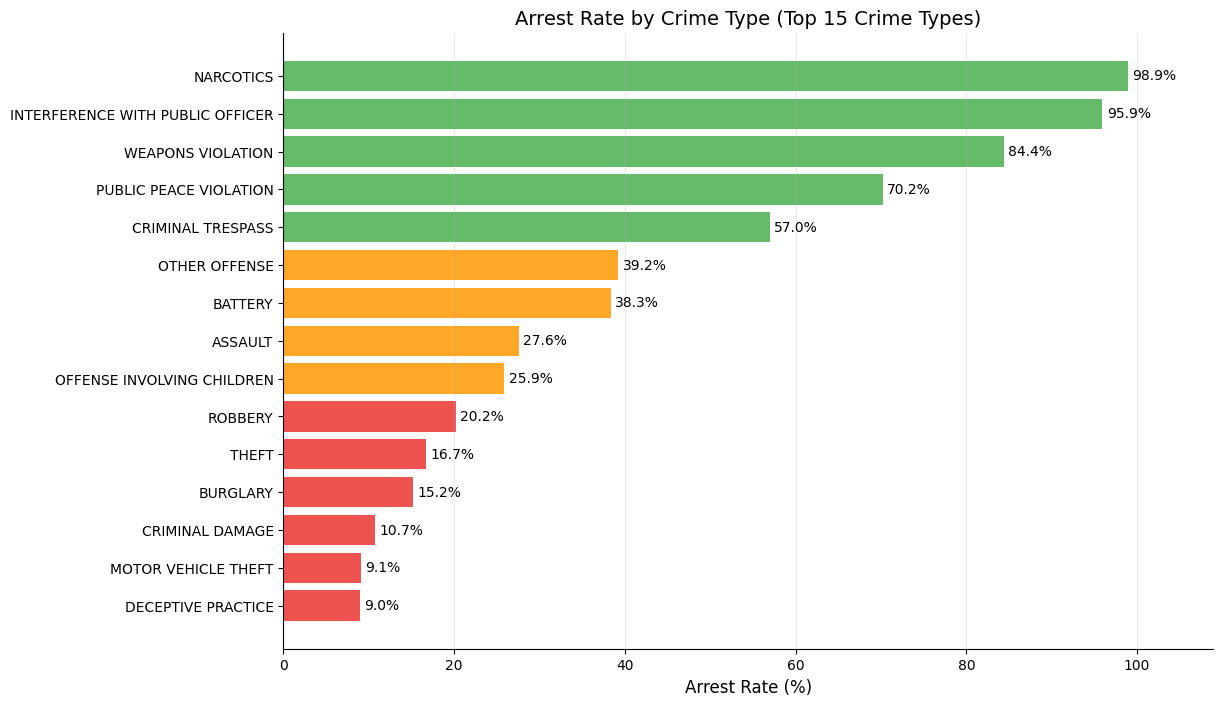

In [120]:
# Compute arrest rate by crime type (Top 15 by total incident count)
arrest_by_type = df.groupby('Primary Type').agg(
    Total_Incidents=('Arrest', 'size'),
    Total_Arrests=('Arrest', 'sum')
)
arrest_by_type['Arrest_Rate'] = (arrest_by_type['Total_Arrests'] / arrest_by_type['Total_Incidents']) * 100

# Keep top 15 crime types by total incident count
arrest_by_type = arrest_by_type.sort_values('Total_Incidents', ascending=False).head(15)

# Sort by arrest rate for a cleaner horizontal bar chart
arrest_by_type = arrest_by_type.sort_values('Arrest_Rate', ascending=True)

fig, ax = plt.subplots(figsize=(12, 8))

colors_arrest = ['#66BB6A' if r > 50 else '#FFA726' if r > 25 else '#EF5350'
                 for r in arrest_by_type['Arrest_Rate']]

ax.barh(range(len(arrest_by_type)), arrest_by_type['Arrest_Rate'],
        color=colors_arrest)
ax.set_yticks(range(len(arrest_by_type)))
ax.set_yticklabels(arrest_by_type.index)
ax.set_xlabel('Arrest Rate (%)')
ax.set_title('Arrest Rate by Crime Type (Top 15 Crime Types)')

for i, (_, row) in enumerate(arrest_by_type.iterrows()):
    ax.text(row['Arrest_Rate'] + 0.5, i, f"{row['Arrest_Rate']:.1f}%",
            va='center')

ax.grid(axis='x', alpha=0.3)
ax.set_xlim(0, max(arrest_by_type['Arrest_Rate']) + 10)
plt.show()

### 7.2 Crime Type Trends Over Time

How have the top crime categories changed over the years?

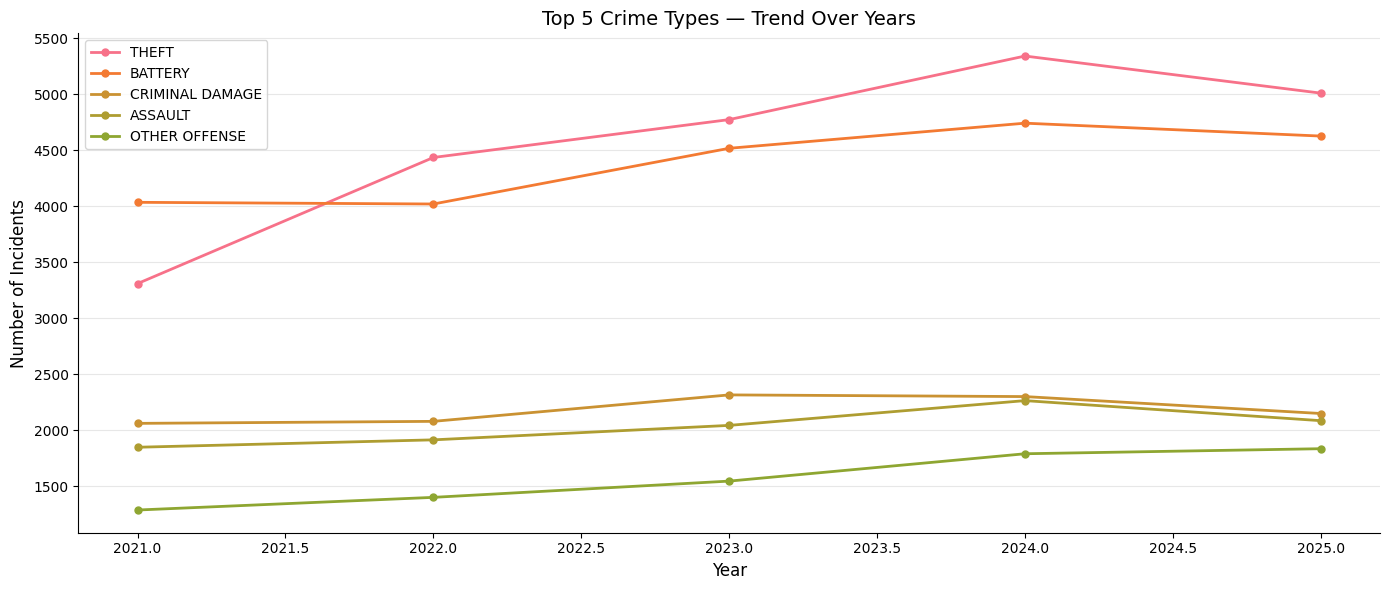

In [143]:
# Top 5 crime types over years
top5_crimes = df['Primary Type'].value_counts().head(5).index
crime_year = df[df['Primary Type'].isin(top5_crimes)].groupby(['Year', 'Primary Type']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(14, 6))
for i, crime in enumerate(top5_crimes):
    if crime in crime_year.columns:
        ax.plot(crime_year.index, crime_year[crime], marker='o',
                label=crime, linewidth=2, markersize=5, color=PALETTE[i])

ax.set_title('Top 5 Crime Types — Trend Over Years')
ax.set_xlabel('Year')
ax.set_ylabel('Number of Incidents')
ax.legend(loc='best')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

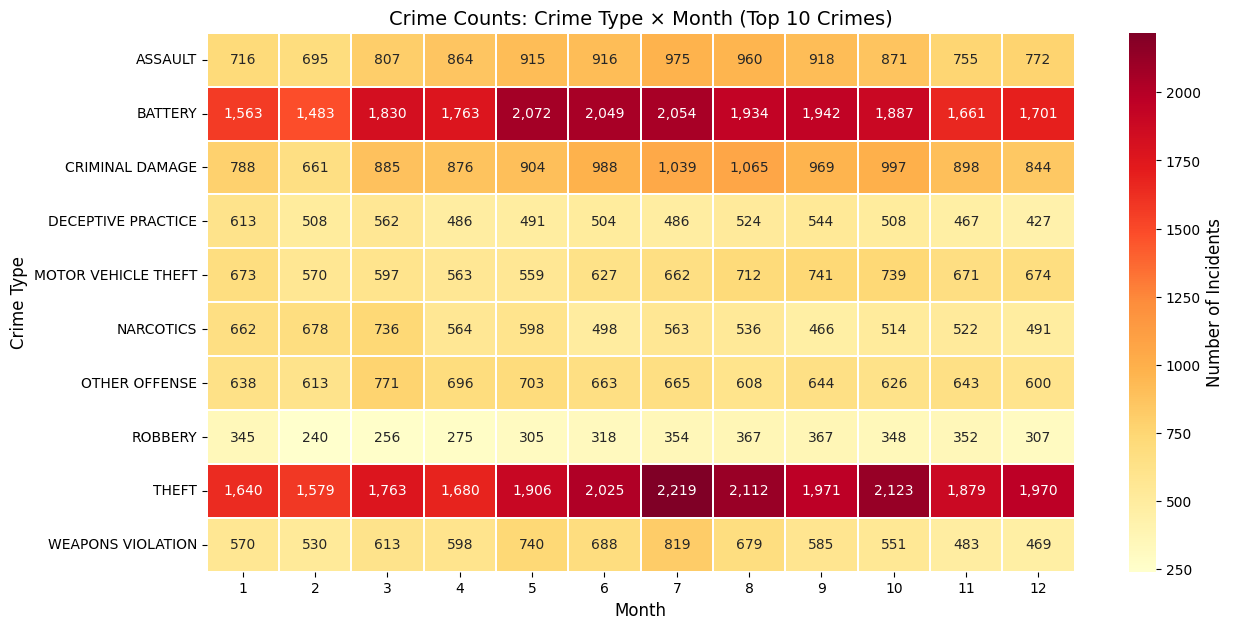

In [151]:
# Crime Type × Month Heatmap
top10_crimes = df['Primary Type'].value_counts().head(10).index
crime_month = df[df['Primary Type'].isin(top10_crimes)].groupby(
    ['Month', 'Primary Type']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(14, 7))
sns.heatmap(crime_month.T, annot=True, fmt=',d', cmap='YlOrRd',
            ax=ax, linewidths=0.25, cbar_kws={'label': 'Number of Incidents'})
ax.set_title('Crime Counts: Crime Type × Month (Top 10 Crimes)')
ax.set_xlabel('Month')
ax.set_ylabel('Crime Type')
plt.show()

### 7.3 Crime Type vs Location

Which crime types are most common at which locations?

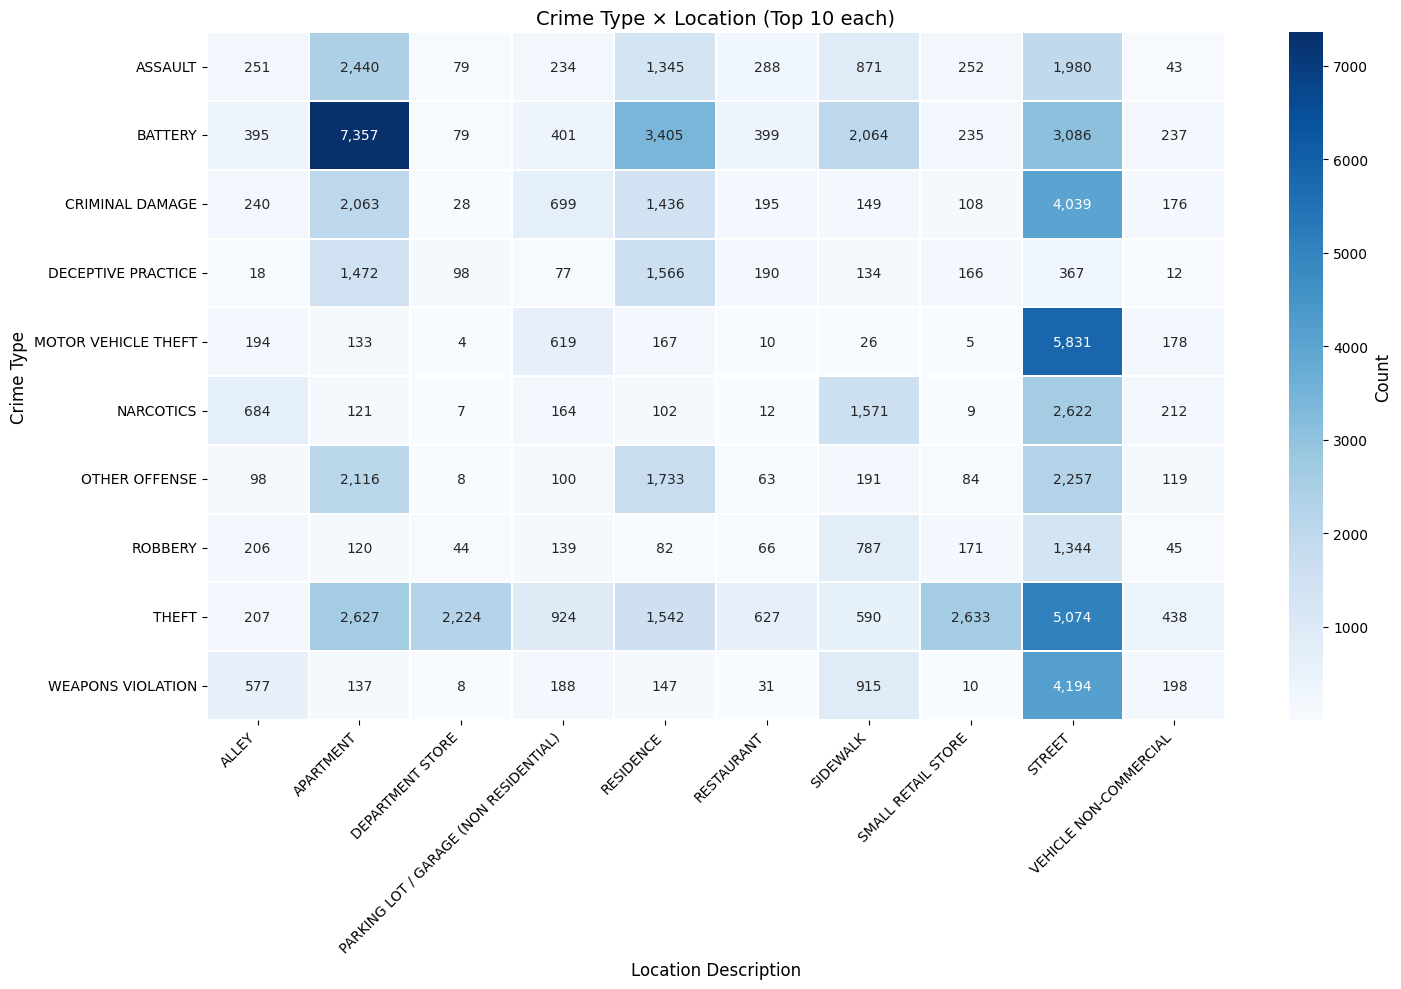

In [155]:
# Crime Type × Location heatmap (top 8 each)
top10_crimes = df['Primary Type'].value_counts().head(10).index
top10_locs = df['Location Description'].value_counts().head(10).index

crime_loc = df[df['Primary Type'].isin(top10_crimes) & df['Location Description'].isin(top10_locs)] \
    .groupby(['Primary Type', 'Location Description']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(15, 10))
sns.heatmap(crime_loc, annot=True, fmt=',d', cmap='Blues', linewidths=0.25,
            cbar_kws={'label': 'Count'})
ax.set_title('Crime Type × Location (Top 10 each)')
ax.set_xlabel('Location Description')
ax.set_ylabel('Crime Type')
plt.xticks(rotation=45,ha='right')
plt.tight_layout()
plt.show()

### 7.4 Crime vs Day of Week (by crime type)

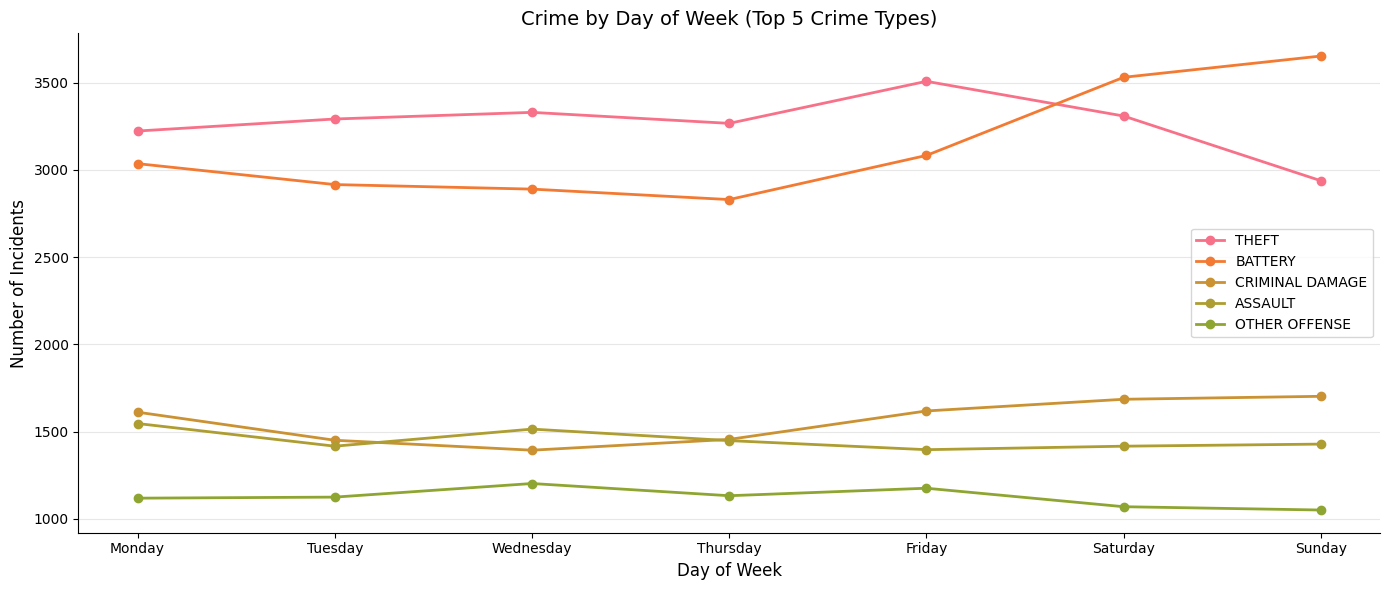

In [156]:
# Crime type by day of week (top 5)
dow_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
top5 = df['Primary Type'].value_counts().head(5).index

fig, ax = plt.subplots(figsize=(14, 6))
for i, crime in enumerate(top5):
    subset = df[df['Primary Type'] == crime]
    dow_counts_crime = subset['Day_of_Week'].value_counts().reindex(dow_order)
    ax.plot(dow_order, dow_counts_crime.values, marker='o', label=crime,
            linewidth=2, markersize=6, color=PALETTE[i])

ax.set_title('Crime by Day of Week (Top 5 Crime Types)')
ax.set_xlabel('Day of Week')
ax.set_ylabel('Number of Incidents')
ax.legend(loc='best', fontsize=10)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### 7.5 Crime vs Hour (by crime type)

Different crime types may show different hourly patterns.

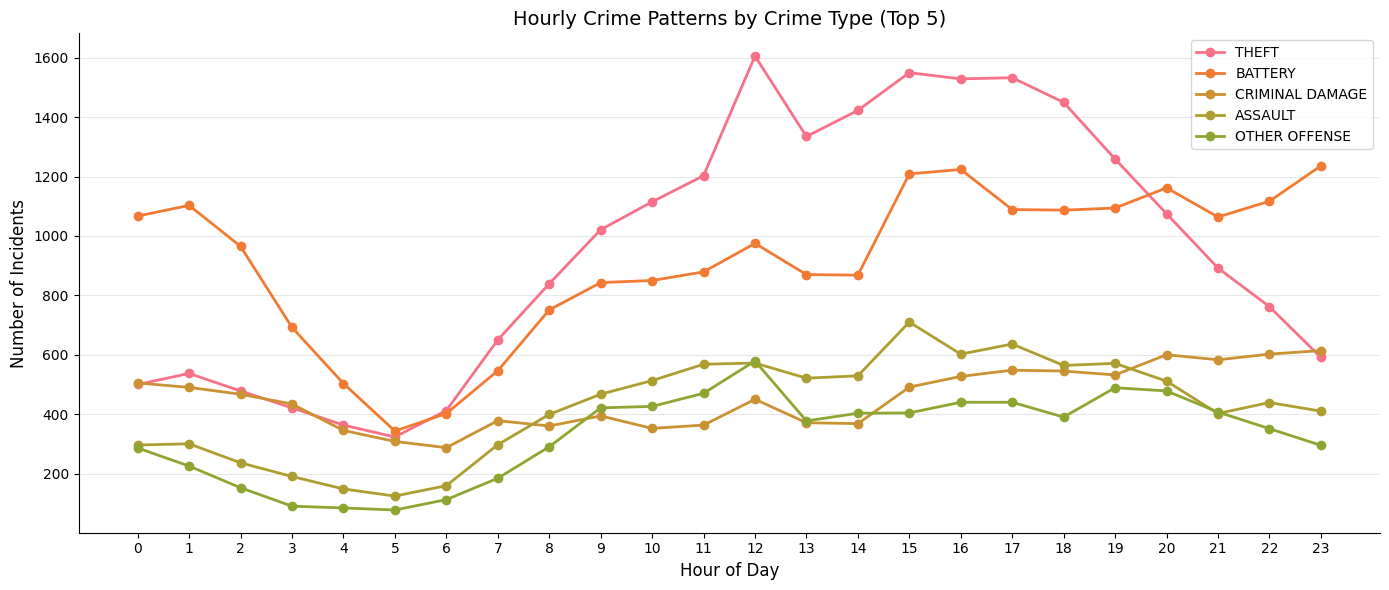

In [158]:
# Hourly patterns by crime type (top 5)
fig, ax = plt.subplots(figsize=(14, 6))
for i, crime in enumerate(top5):
    subset = df[df['Primary Type'] == crime]
    hourly = subset['Hour'].value_counts().sort_index()
    ax.plot(hourly.index, hourly.values, label=crime, linewidth=2, color=PALETTE[i], marker='o')

ax.set_title('Hourly Crime Patterns by Crime Type (Top 5)')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Number of Incidents')
ax.set_xticks(range(24))
ax.legend(loc='best', fontsize=10)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### 7.6 Arrest Rate vs Time

Has the arrest rate changed over time?

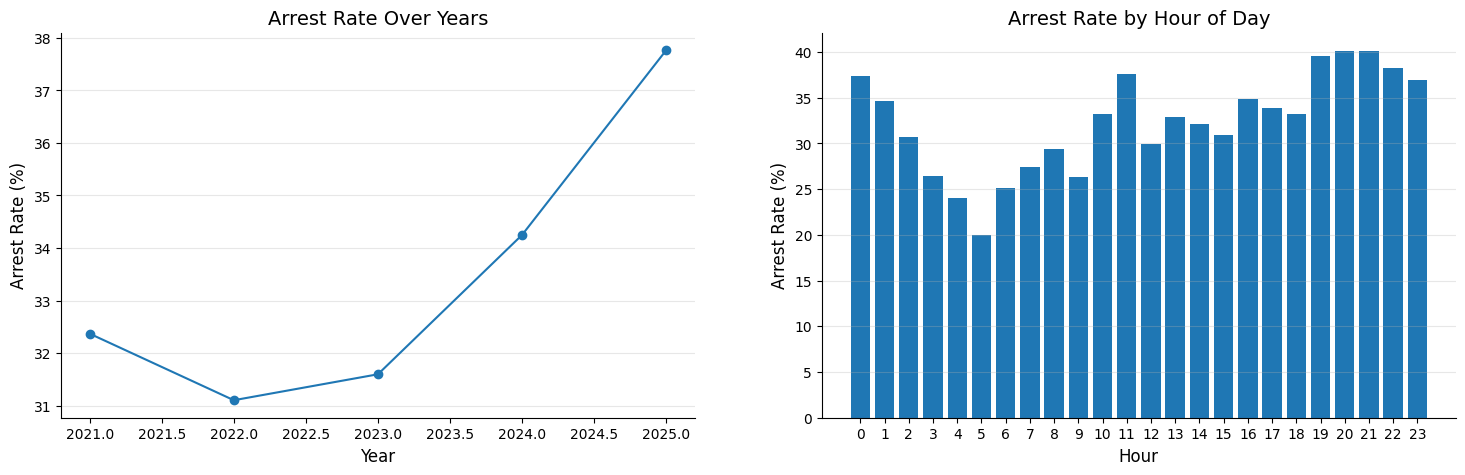

In [166]:
# Arrest rate over years
arrest_year = df.groupby('Year')['Arrest'].mean() * 100

fig, (ax1,ax2) = plt.subplots(1, 2, figsize=(18, 5))

# By Year
ax1.plot(arrest_year.index, arrest_year.values, marker='o')
ax1.set_title('Arrest Rate Over Years')
ax1.set_xlabel('Year')
ax1.set_ylabel('Arrest Rate (%)')
ax1.grid(axis='y', alpha=0.3)

# By Hour
arrest_hour = df.groupby('Hour')['Arrest'].mean() * 100
ax2.bar(arrest_hour.index, arrest_hour.values)
ax2.set_title('Arrest Rate by Hour of Day')
ax2.set_xlabel('Hour')
ax2.set_ylabel('Arrest Rate (%)')
ax2.set_xticks(range(24))
ax2.grid(axis='y', alpha=0.3)

plt.show()

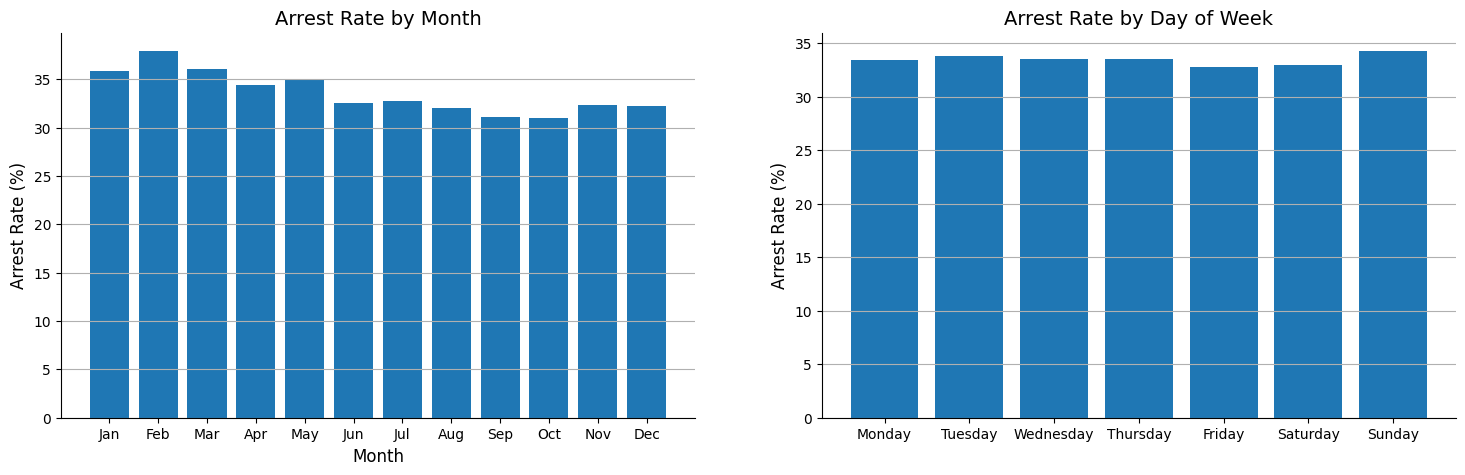

In [169]:
# Arrest rate by month and day of week
fig, (ax1,ax2)= plt.subplots(1, 2, figsize=(18, 5))

# By Month
arrest_month = df.groupby('Month')['Arrest'].mean() * 100
ax1.bar(range(1, 13), arrest_month.values)
ax1.set_title('Arrest Rate by Month')
ax1.set_xlabel('Month')
ax1.set_ylabel('Arrest Rate (%)')
ax1.set_xticks(range(1, 13))
ax1.set_xticklabels([m[:3] for m in month_order])
ax1.grid(axis='y')

# By Day of Week
arrest_dow = df.groupby('Day_of_Week')['Arrest'].mean().reindex(dow_order) * 100
ax2.bar(dow_order, arrest_dow.values)
ax2.set_title('Arrest Rate by Day of Week')
ax2.set_ylabel('Arrest Rate (%)')
ax2.grid(axis='y')

plt.show()

## 8. Multivariate Analysis

Deeper analysis using combinations of three or more variables.

### 8.1 Day of Week × Hour Crime Heatmap

One of the most revealing visualizations — showing crime density across the entire week.

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


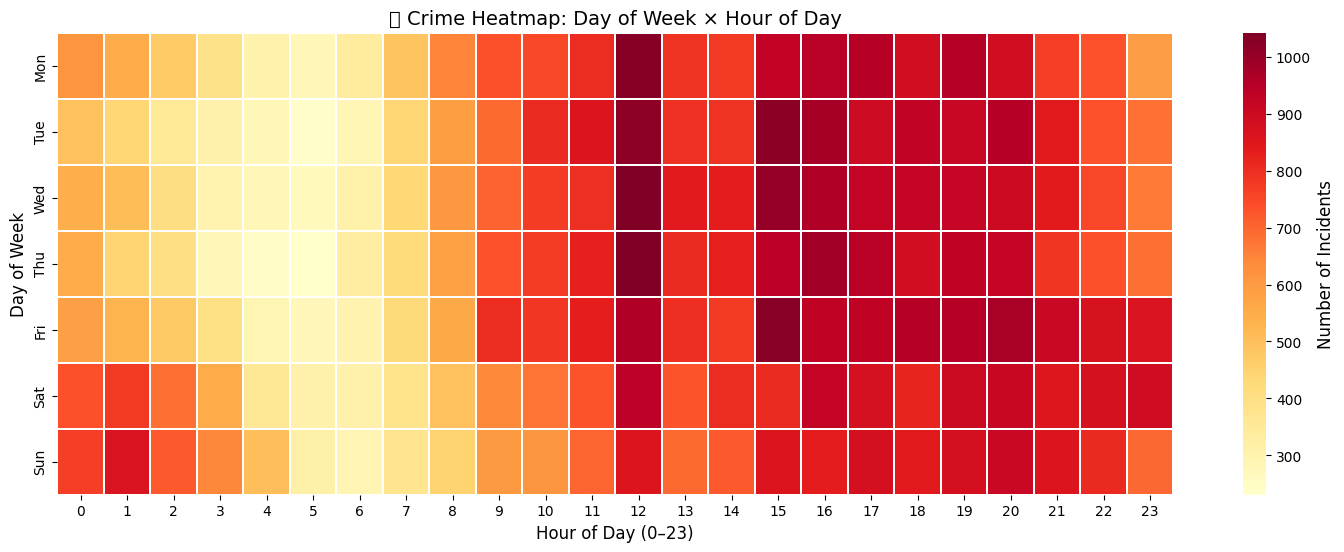

Peak combinations (Day × Hour):
  Wednesday  at 12:00 → 1,042 incidents
  Thursday   at 12:00 → 1,041 incidents
  Monday     at 12:00 → 1,031 incidents
  Friday     at 15:00 → 1,028 incidents
  Tuesday    at 15:00 → 1,018 incidents


In [170]:
# Day of Week × Hour Crime Heatmap
dow_hour = df.groupby(['Day_of_Week_Num', 'Hour']).size().unstack(fill_value=0)
dow_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

fig, ax = plt.subplots(figsize=(18, 6))
sns.heatmap(dow_hour, cmap='YlOrRd', ax=ax, linewidths=0.3,
            yticklabels=dow_labels, annot=False,
            cbar_kws={'label': 'Number of Incidents'})
ax.set_title('🔥 Crime Heatmap: Day of Week × Hour of Day')
ax.set_xlabel('Hour of Day (0–23)')
ax.set_ylabel('Day of Week')
plt.show()

# Summary statistics
print("Peak combinations (Day × Hour):")
dow_hour_flat = df.groupby(['Day_of_Week', 'Hour']).size().reset_index(name='Count')
top5_combos = dow_hour_flat.nlargest(5, 'Count')
for _, row in top5_combos.iterrows():
    print(f"  {row['Day_of_Week']:10s} at {int(row['Hour']):02d}:00 → {row['Count']:,} incidents")

### 8.2 Crime Type × Hour × Arrest Rate

Does arrest probability differ by crime type and time of day?

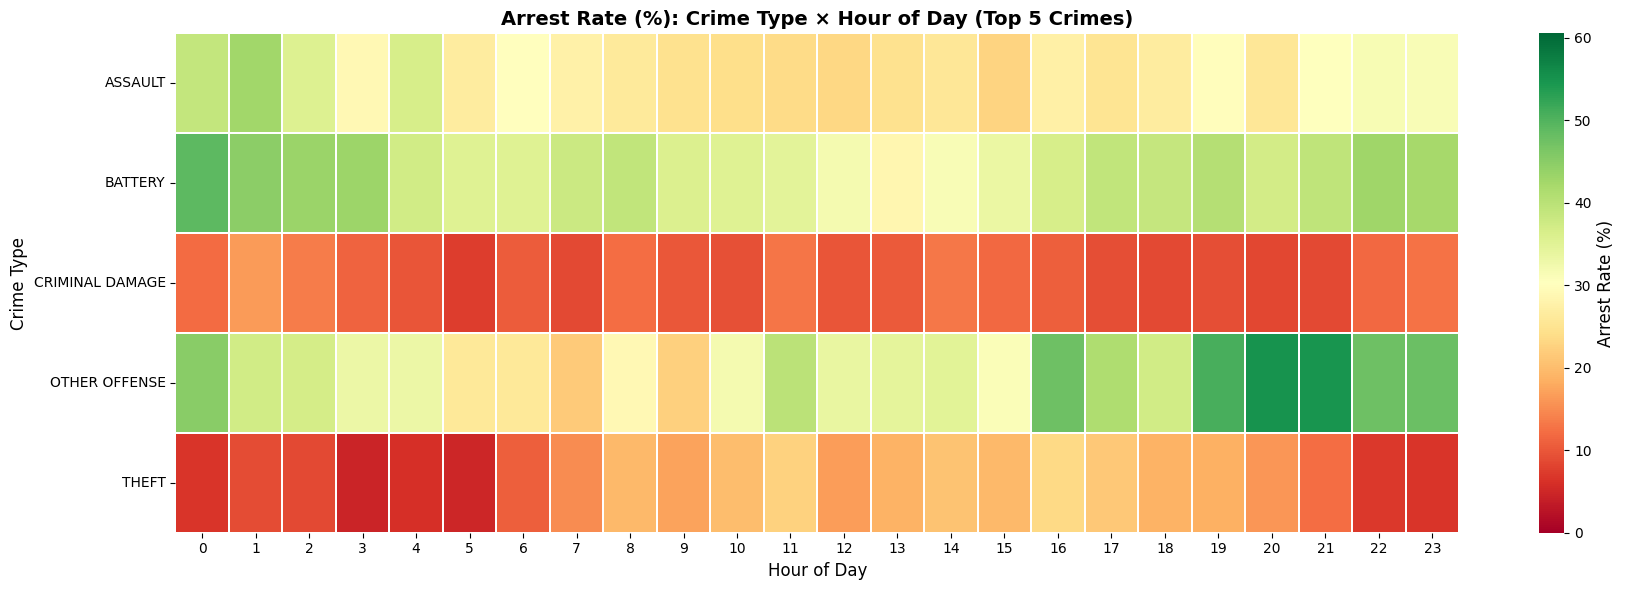

In [129]:
# Crime Type × Hour × Arrest Rate heatmap
top5 = df['Primary Type'].value_counts().head(5).index
subset = df[df['Primary Type'].isin(top5)]

pivot = subset.groupby(['Primary Type', 'Hour'])['Arrest'].mean().unstack(fill_value=0) * 100

fig, ax = plt.subplots(figsize=(18, 6))
sns.heatmap(pivot, cmap='RdYlGn', ax=ax, linewidths=0.3,
            vmin=0, vmax=pivot.values.max() * 1.1,
            cbar_kws={'label': 'Arrest Rate (%)'})
ax.set_title('Arrest Rate (%): Crime Type × Hour of Day (Top 5 Crimes)',
              fontsize=14, fontweight='bold')
ax.set_xlabel('Hour of Day', fontsize=12)
ax.set_ylabel('Crime Type', fontsize=12)
plt.tight_layout()
plt.show()

### 8.3 Crime Type × Month (Seasonal Patterns)

Do different crime categories have seasonal patterns?

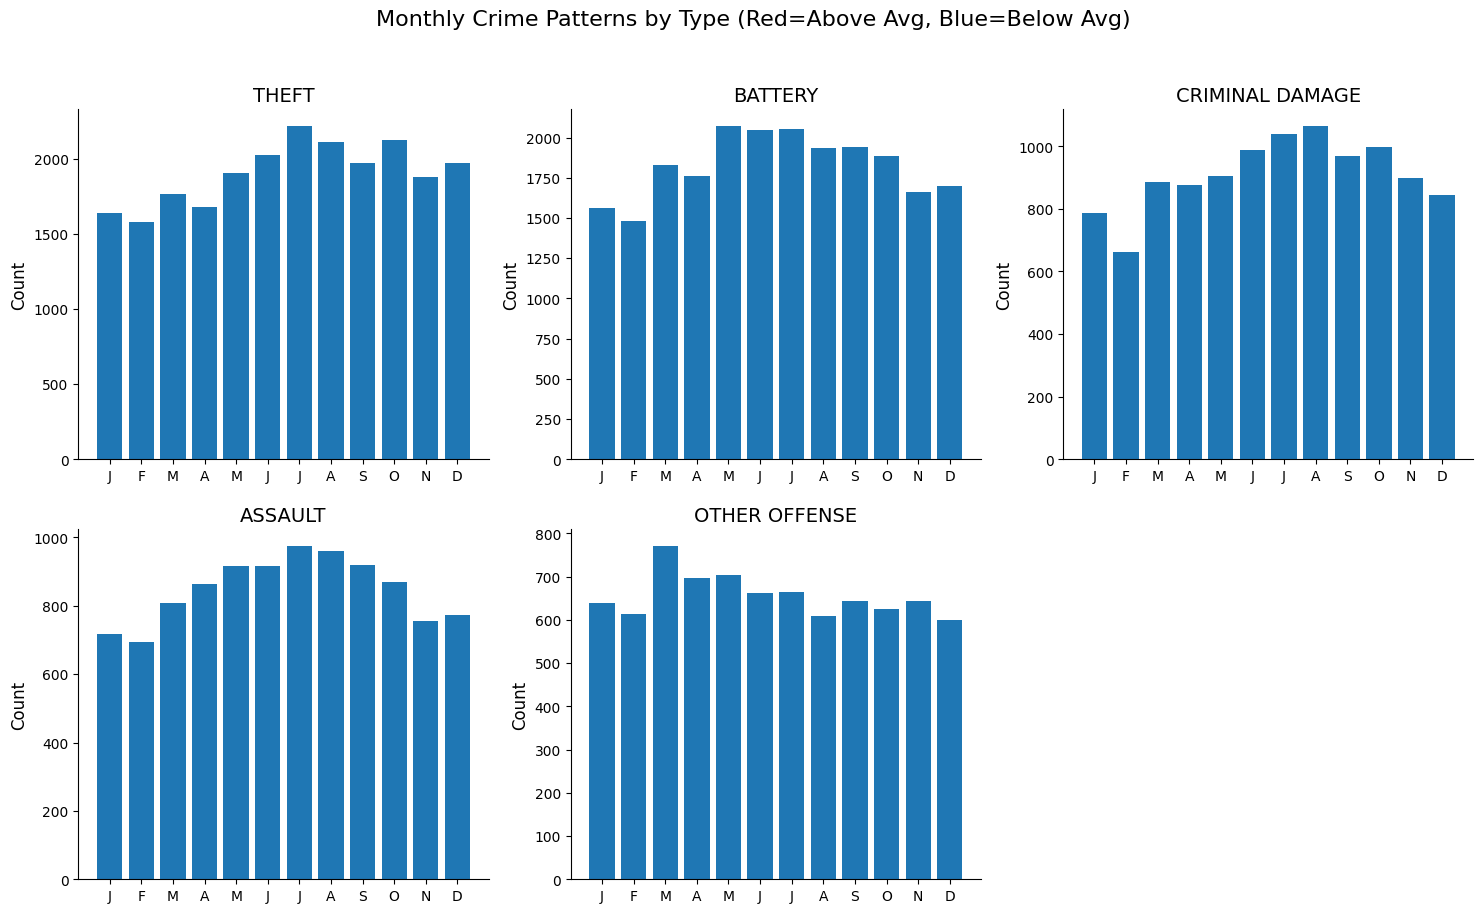

In [130]:
# Seasonal patterns - normalized by crime type to show relative patterns
top5 = df['Primary Type'].value_counts().head(5).index
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, crime in enumerate(top5):
    subset = df[df['Primary Type'] == crime]
    monthly = subset["Month"].value_counts().sort_index()
    avg = monthly.mean()

    axes[i].bar(range(1, 13), monthly.values)
    axes[i].set_title(crime)
    axes[i].set_xticks(range(1, 13))
    axes[i].set_xticklabels([m[:1] for m in month_order])
    axes[i].set_ylabel('Count')

# Remove unused subplot
axes[5].axis('off')
plt.suptitle('Monthly Crime Patterns by Type (Red=Above Avg, Blue=Below Avg)')
plt.show()

### 8.4 District × Crime Type

Which districts have unusually high concentrations of particular crime categories?

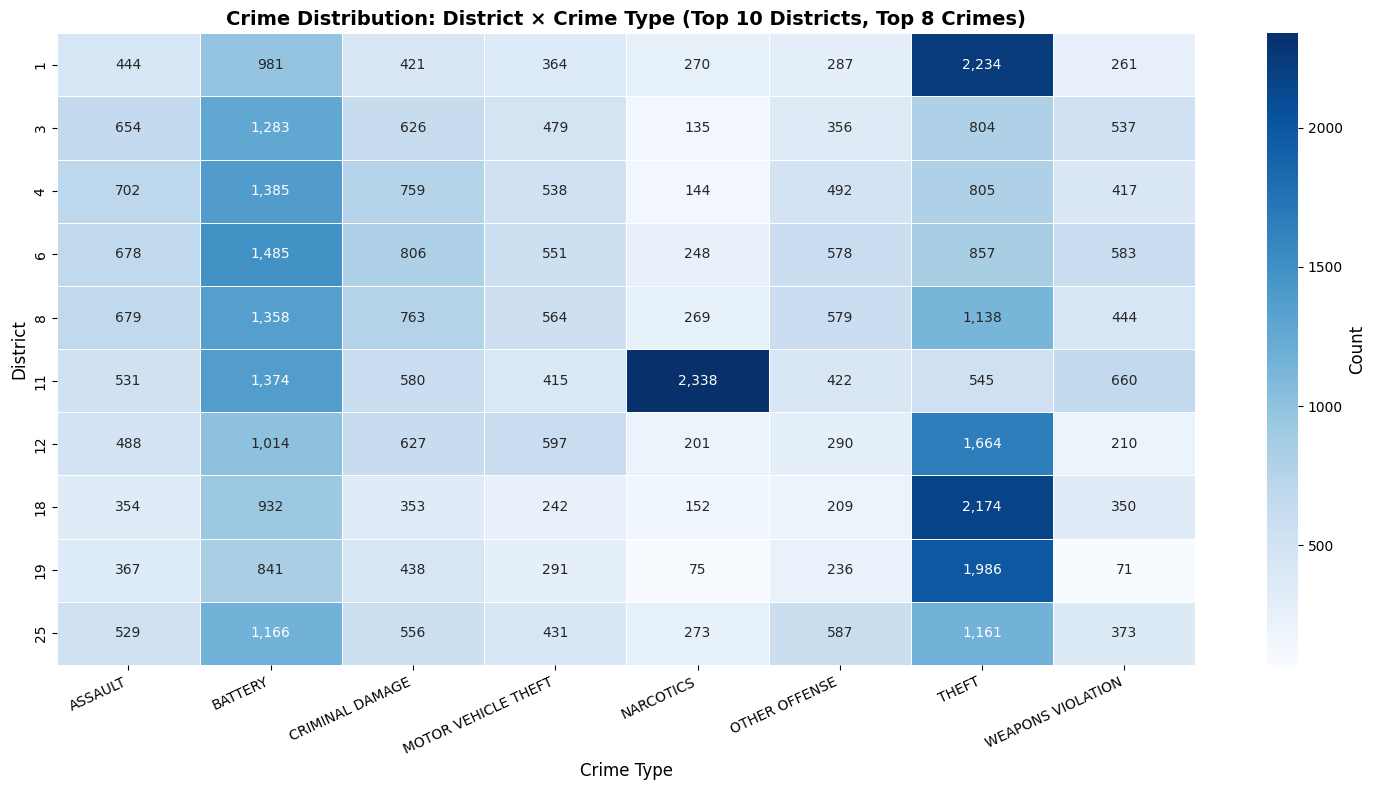

In [131]:
# District × Crime Type heatmap
top8_crimes = df['Primary Type'].value_counts().head(8).index
top10_districts = df['District'].value_counts().head(10).index.astype(int)

dist_crime = df[df['Primary Type'].isin(top8_crimes) & df['District'].isin(top10_districts)] \
    .groupby(['District', 'Primary Type']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(15, 8))
sns.heatmap(dist_crime, annot=True, fmt=',d', cmap='Blues', ax=ax, linewidths=0.5,
            cbar_kws={'label': 'Count'})
ax.set_title('Crime Distribution: District × Crime Type (Top 10 Districts, Top 8 Crimes)',
              fontsize=14, fontweight='bold')
ax.set_xlabel('Crime Type', fontsize=12)
ax.set_ylabel('District', fontsize=12)
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.show()

## 9. Geographic Analysis

Analyzing the spatial distribution of crimes using latitude and longitude data.

In [132]:
# Filter to valid geographic coordinates
geo = df.dropna(subset=['Latitude', 'Longitude'])
geo = geo[(geo['Latitude'] > 41.6) & (geo['Latitude'] < 42.1) &
          (geo['Longitude'] > -87.95) & (geo['Longitude'] < -87.5)]

print(f"Records with valid coordinates: {len(geo):,} / {len(df):,} ({len(geo)/len(df)*100:.1f}%)")
print(f"Records excluded (missing/invalid coords): {len(df) - len(geo):,}")

Records with valid coordinates: 115,061 / 116,687 (98.6%)
Records excluded (missing/invalid coords): 1,626


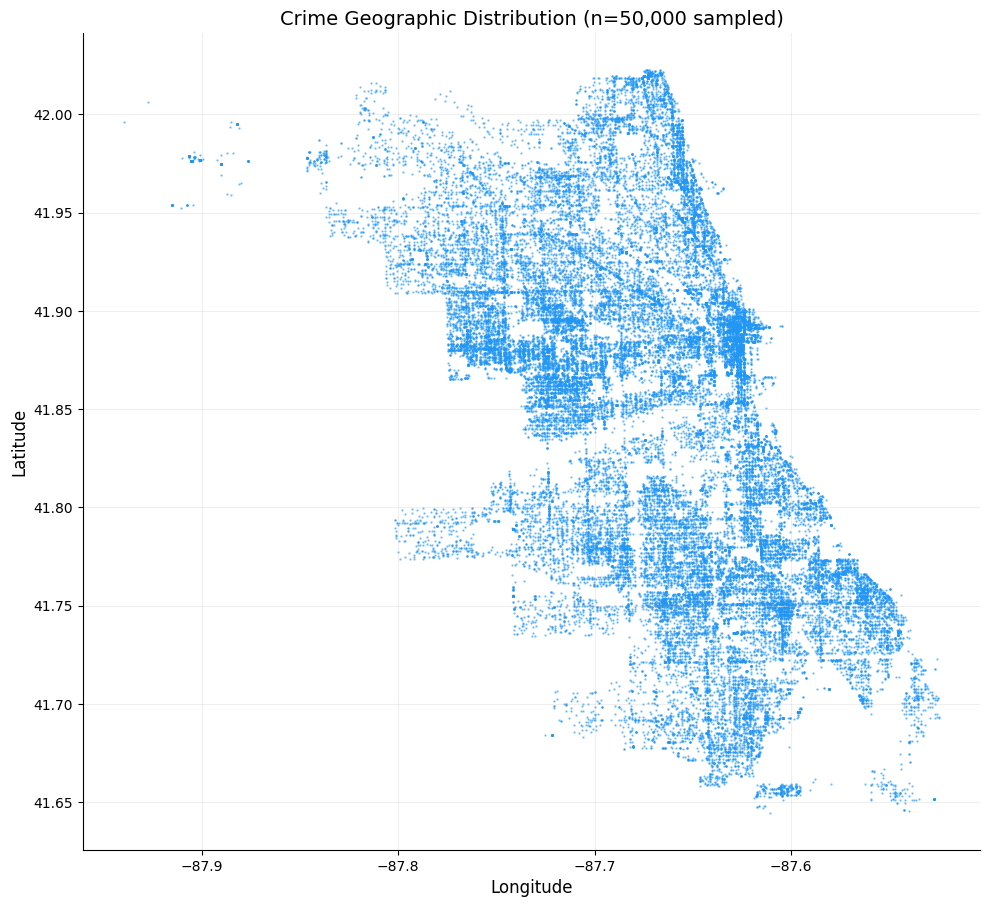

In [133]:
# Overall crime geographic scatter plot
fig, ax = plt.subplots(figsize=(10, 12))

# Sample for performance (large datasets)
sample_size = min(50000, len(geo))
geo_sample = geo.sample(n=sample_size, random_state=42)

ax.scatter(geo_sample['Longitude'], geo_sample['Latitude'],s=0.5, alpha=0.5, c=ACCENT)
ax.set_title(f'Crime Geographic Distribution (n={sample_size:,} sampled)')
ax.set_xlabel('Longitude', fontsize=12)
ax.set_ylabel('Latitude', fontsize=12)
ax.set_aspect('equal')
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

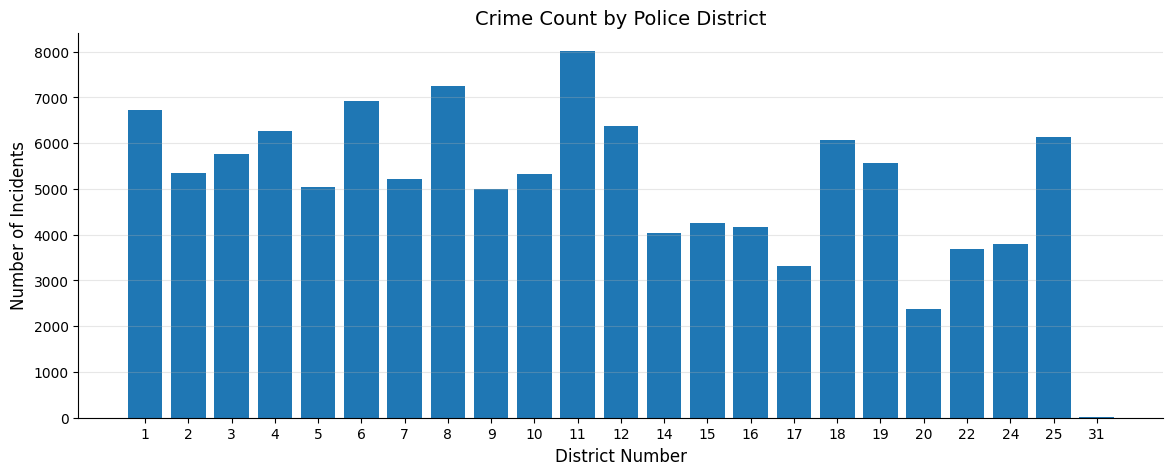


Highest crime district: 11 (8,014 incidents)
Lowest crime district:  31 (8 incidents)


In [134]:
# Crime density by district (bar + stats)
district_counts = df['District'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(14, 5))
bars = ax.bar(district_counts.index.astype(int).astype(str), district_counts.values)
ax.set_title('Crime Count by Police District')
ax.set_xlabel('District Number')
ax.set_ylabel('Number of Incidents')
ax.grid(axis='y', alpha=0.3)
plt.show()

print(f"\nHighest crime district: {int(district_counts.idxmax())} ({district_counts.max():,} incidents)")
print(f"Lowest crime district:  {int(district_counts.idxmin())} ({district_counts.min():,} incidents)")

## 10. Correlation Analysis

Identify meaningful numerical correlations — excluding arbitrary IDs.

Meaningful numerical columns for correlation: ['Beat', 'District', 'Ward', 'Community Area', 'Year', 'Latitude', 'Longitude', 'Month', 'Day', 'Day_of_Week_Num', 'Hour', 'Quarter', 'Is_Weekend']


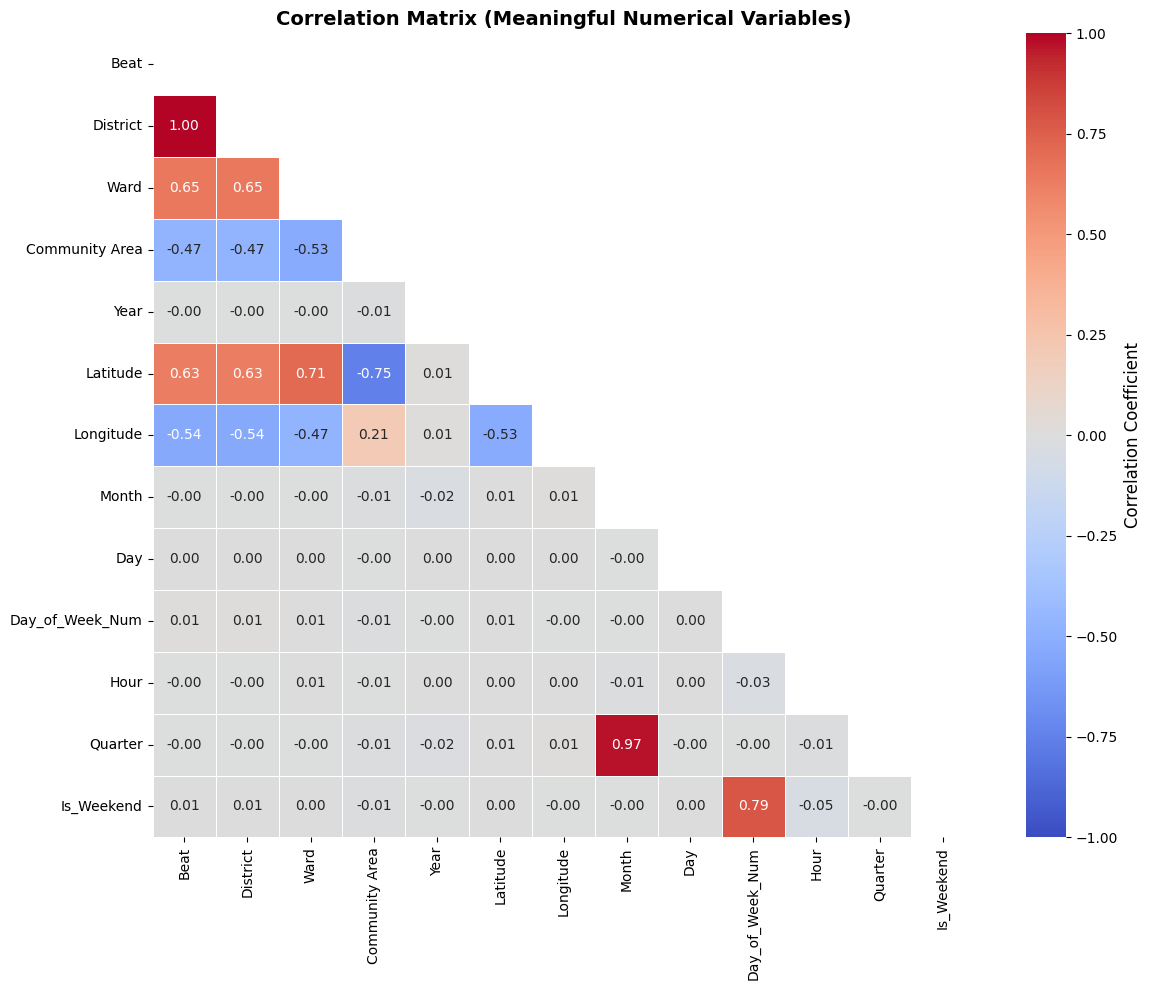


Notable Correlations (|r| > 0.3, excluding diagonal):
  Beat ↔ District: r = 1.000 (Strong positive)
  Beat ↔ Ward: r = 0.650 (Moderate positive)
  Beat ↔ Community Area: r = -0.472 (Weak-Moderate negative)
  Beat ↔ Latitude: r = 0.629 (Moderate positive)
  Beat ↔ Longitude: r = -0.536 (Moderate negative)
  District ↔ Ward: r = 0.651 (Moderate positive)
  District ↔ Community Area: r = -0.472 (Weak-Moderate negative)
  District ↔ Latitude: r = 0.630 (Moderate positive)
  District ↔ Longitude: r = -0.537 (Moderate negative)
  Ward ↔ Community Area: r = -0.529 (Moderate negative)
  Ward ↔ Latitude: r = 0.712 (Strong positive)
  Ward ↔ Longitude: r = -0.472 (Weak-Moderate negative)
  Community Area ↔ Latitude: r = -0.753 (Strong negative)
  Latitude ↔ Longitude: r = -0.529 (Moderate negative)
  Month ↔ Quarter: r = 0.970 (Strong positive)
  Day_of_Week_Num ↔ Is_Weekend: r = 0.789 (Strong positive)

⚠️ Note: Correlations between geographic area codes (District, Beat, Ward)
   reflect admi

In [135]:
# Select meaningful numerical columns (exclude IDs and coordinates)
exclude_patterns = ['id', 'case', 'x_coord', 'y_coord', 'x coord', 'y coord',
                    'updated', '_year']
meaningful_num = []
for c in df.select_dtypes(include=[np.number]).columns:
    if not any(pat in c.lower().replace(' ', '_') for pat in exclude_patterns):
        meaningful_num.append(c)

print(f"Meaningful numerical columns for correlation: {meaningful_num}")

if len(meaningful_num) >= 2:
    corr = df[meaningful_num].corr()

    fig, ax = plt.subplots(figsize=(12, 10))
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
                center=0, ax=ax, linewidths=0.5, vmin=-1, vmax=1,
                cbar_kws={'label': 'Correlation Coefficient'})
    ax.set_title('Correlation Matrix (Meaningful Numerical Variables)',
                  fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # Report notable correlations
    print("\nNotable Correlations (|r| > 0.3, excluding diagonal):")
    found = False
    for i in range(len(corr.columns)):
        for j in range(i + 1, len(corr.columns)):
            r = corr.iloc[i, j]
            if abs(r) > 0.3:
                found = True
                strength = "Strong" if abs(r) > 0.7 else "Moderate" if abs(r) > 0.5 else "Weak-Moderate"
                direction = "positive" if r > 0 else "negative"
                print(f"  {corr.columns[i]} ↔ {corr.columns[j]}: r = {r:.3f} ({strength} {direction})")
    if not found:
        print("  No correlations above |0.3| found among these variables.")

    print("\n⚠️ Note: Correlations between geographic area codes (District, Beat, Ward)")
    print("   reflect administrative boundaries, not meaningful crime relationships.")
else:
    print("Not enough meaningful numerical columns for correlation analysis.")

## 11. Statistical Analysis

Supplementing visual observations with formal statistical tests where appropriate.

### 11.1 Chi-square Test: Crime Type × Arrest

**H₀:** Arrest outcome is independent of crime type.  
**H₁:** Arrest outcome depends on crime type.

In [136]:
# Chi-square: Crime Type × Arrest
top10_crimes = df['Primary Type'].value_counts().head(10).index
subset = df[df['Primary Type'].isin(top10_crimes)]
contingency = pd.crosstab(subset['Primary Type'], subset['Arrest'])

chi2, p_val, dof, expected = stats.chi2_contingency(contingency)

print("Chi-square Test: Crime Type × Arrest Outcome")
print("=" * 55)
print(f"H₀: Arrest outcome is independent of crime type.")
print(f"H₁: Arrest outcome depends on crime type.")
print(f"")
print(f"Chi-square statistic: {chi2:,.2f}")
print(f"Degrees of freedom:   {dof}")
print(f"P-value:              {p_val:.2e}")

# Effect size: Cramér's V
n = contingency.sum().sum()
min_dim = min(contingency.shape) - 1
cramers_v = np.sqrt(chi2 / (n * min_dim))

print(f"Cramér's V:           {cramers_v:.3f}")

if p_val < 0.05:
    print(f"\n✅ REJECT H₀ (p < 0.05): Statistically significant association")
    print(f"   between crime type and arrest outcome.")
    if cramers_v < 0.1:
        print(f"   Effect size: Weak (V < 0.1)")
    elif cramers_v < 0.3:
        print(f"   Effect size: Moderate (0.1 ≤ V < 0.3)")
    else:
        print(f"   Effect size: Strong (V ≥ 0.3)")
else:
    print(f"\n❌ FAIL TO REJECT H₀: No significant association found.")

Chi-square Test: Crime Type × Arrest Outcome
H₀: Arrest outcome is independent of crime type.
H₁: Arrest outcome depends on crime type.

Chi-square statistic: 32,075.63
Degrees of freedom:   9
P-value:              0.00e+00
Cramér's V:           0.551

✅ REJECT H₀ (p < 0.05): Statistically significant association
   between crime type and arrest outcome.
   Effect size: Strong (V ≥ 0.3)


### 11.2 Chi-square Test: Crime Type × Domestic

**H₀:** Domestic classification is independent of crime type.  
**H₁:** Domestic classification depends on crime type.

In [137]:
# Chi-square: Crime Type × Domestic
contingency2 = pd.crosstab(subset['Primary Type'], subset['Domestic'])
chi2_2, p_val_2, dof_2, _ = stats.chi2_contingency(contingency2)

n2 = contingency2.sum().sum()
min_dim2 = min(contingency2.shape) - 1
cramers_v2 = np.sqrt(chi2_2 / (n2 * min_dim2))

print("Chi-square Test: Crime Type × Domestic Classification")
print("=" * 55)
print(f"H₀: Domestic classification is independent of crime type.")
print(f"H₁: Domestic classification depends on crime type.")
print(f"")
print(f"Chi-square statistic: {chi2_2:,.2f}")
print(f"P-value:              {p_val_2:.2e}")
print(f"Cramér's V:           {cramers_v2:.3f}")

if p_val_2 < 0.05:
    print(f"\n✅ REJECT H₀: Significant association between crime type and domestic classification.")
    if cramers_v2 >= 0.3:
        print(f"   This is a strong association (V = {cramers_v2:.3f}).")
else:
    print(f"\n❌ FAIL TO REJECT H₀.")

Chi-square Test: Crime Type × Domestic Classification
H₀: Domestic classification is independent of crime type.
H₁: Domestic classification depends on crime type.

Chi-square statistic: 29,179.38
P-value:              0.00e+00
Cramér's V:           0.526

✅ REJECT H₀: Significant association between crime type and domestic classification.
   This is a strong association (V = 0.526).


### 11.3 Weekend vs Weekday Crime Comparison

In [138]:
# Weekend vs Weekday comparison
weekend = df[df['Is_Weekend'] == 1]
weekday = df[df['Is_Weekend'] == 0]

print("Weekend vs Weekday Crime Comparison")
print("=" * 50)
print(f"Weekend total incidents: {len(weekend):,}")
print(f"Weekday total incidents: {len(weekday):,}")

# Normalize per day
n_years = df['Year'].nunique()
weekend_daily = len(weekend) / (2 * n_years * 52)  # ~2 weekend days per week
weekday_daily = len(weekday) / (5 * n_years * 52)  # ~5 weekday days per week

print(f"\nEstimated daily average:")
print(f"  Weekend: ~{weekend_daily:.0f} crimes/day")
print(f"  Weekday: ~{weekday_daily:.0f} crimes/day")
print(f"  Ratio (Weekend/Weekday): {weekend_daily/weekday_daily:.2f}")

# Arrest rate comparison
weekend_arrest = weekend['Arrest'].mean() * 100
weekday_arrest = weekday['Arrest'].mean() * 100
print(f"\nArrest rates:")
print(f"  Weekend: {weekend_arrest:.1f}%")
print(f"  Weekday: {weekday_arrest:.1f}%")

Weekend vs Weekday Crime Comparison
Weekend total incidents: 33,679
Weekday total incidents: 83,008

Estimated daily average:
  Weekend: ~65 crimes/day
  Weekday: ~64 crimes/day
  Ratio (Weekend/Weekday): 1.01

Arrest rates:
  Weekend: 33.6%
  Weekday: 33.4%


## 12. Key Findings from Chicago Crime Data

---

> ⚠️ **Important:** All insights below are derived directly from the dataset analysis. No causal claims are made unless explicitly supported by the data. Correlation ≠ Causation.

The following findings summarize the key conclusions of this analysis. Each is supported by the data and visualizations produced above.

In [139]:
# Generate evidence-based key insights from the actual data
print("=" * 70)
print("  KEY FINDINGS FROM CHICAGO CRIME DATA")
print("=" * 70)

findings = []

# Finding 1: Dataset scope
min_year = df['Year'].min()
max_year = df['Year'].max()
findings.append({
    'title': 'DATASET SCOPE',
    'finding': f"The dataset contains {len(df):,} crime records spanning {min_year}–{max_year}.",
    'evidence': f"{df.shape[1]} columns covering crime type, location, time, arrest status, and geography.",
    'interpretation': "Provides a comprehensive multi-year view of crime in Chicago.",
    'caveat': "Analysis is limited to reported/recorded crimes; unreported crimes are not captured."
})

# Finding 2: Dominant crime type
top_crime = df['Primary Type'].value_counts().head(1)
top_crime_name = top_crime.index[0]
top_crime_pct = top_crime.values[0] / len(df) * 100
top3 = df['Primary Type'].value_counts().head(3)
findings.append({
    'title': 'DOMINANT CRIME TYPE',
    'finding': f"'{top_crime_name}' is the most common crime type ({top_crime_pct:.1f}% of all incidents).",
    'evidence': f"Top 3: {', '.join([f'{c} ({v:,})' for c, v in top3.items()])}",
    'interpretation': f"'{top_crime_name}' substantially outnumbers other categories.",
    'caveat': "High count may reflect reporting patterns rather than actual crime prevalence."
})

# Finding 3: Arrest rate
findings.append({
    'title': 'LOW OVERALL ARREST RATE',
    'finding': f"The overall arrest rate is {overall_arrest_rate:.1f}%.",
    'evidence': f"Arrests: {df['Arrest'].sum():,} / Total: {len(df):,}",
    'interpretation': "A majority of reported crimes do not result in arrest.",
    'caveat': "Low arrest rate does not imply low policing effort; many crimes are hard to solve."
})

# Finding 4: Arrest variation by crime type
highest_arrest_crime = arrest_by_type['Arrest_Rate'].idxmax()
highest_arrest_rate = arrest_by_type['Arrest_Rate'].max()
lowest_arrest_crime = arrest_by_type['Arrest_Rate'].idxmin()
lowest_arrest_rate = arrest_by_type['Arrest_Rate'].min()
findings.append({
    'title': 'ARREST RATE VARIES BY CRIME TYPE',
    'finding': f"Arrest rates range from {lowest_arrest_rate:.1f}% ({lowest_arrest_crime}) to {highest_arrest_rate:.1f}% ({highest_arrest_crime}).",
    'evidence': "See arrest rate by crime type visualization.",
    'interpretation': "Crime types with higher arrest rates may be easier to solve or have different policing priorities.",
    'caveat': "Arrest rate differences may reflect crime characteristics, not policing quality."
})

# Finding 5: Temporal peaks
peak_hour = df['Hour'].value_counts().idxmax()
low_hour = df['Hour'].value_counts().idxmin()
peak_month = df['Month_Name'].value_counts().idxmax()
low_month = df['Month_Name'].value_counts().idxmin()
findings.append({
    'title': 'CLEAR TEMPORAL PATTERNS',
    'finding': f"Crime peaks at {peak_hour}:00 and is lowest at {low_hour}:00. Monthly peak: {peak_month}, lowest: {low_month}.",
    'evidence': "See hourly and monthly distribution charts.",
    'interpretation': "Crime follows distinct daily and seasonal cycles.",
    'caveat': "Temporal patterns may reflect reporting patterns, not actual crime timing."
})

# Finding 6: Location concentration
top_loc = df['Location Description'].value_counts().head(1)
top_loc_pct = top_loc.values[0] / len(df) * 100
findings.append({
    'title': 'LOCATION CONCENTRATION',
    'finding': f"'{top_loc.index[0]}' is the most common crime location ({top_loc_pct:.1f}%).",
    'evidence': "See location distribution chart.",
    'interpretation': "A significant portion of crimes occurs in public spaces.",
    'caveat': "Location categories may overlap or be inconsistently recorded."
})

# Finding 7: Domestic crimes
findings.append({
    'title': 'DOMESTIC CRIME PREVALENCE',
    'finding': f"{domestic_rate:.1f}% of all crimes are classified as domestic.",
    'evidence': f"Domestic incidents: {df['Domestic'].sum():,} out of {len(df):,}",
    'interpretation': "A notable fraction of crime involves domestic situations.",
    'caveat': "Domestic crimes are often underreported; actual rates may be higher."
})

# Finding 8: Day-hour pattern
peak_day = df['Day_of_Week'].value_counts().idxmax()
findings.append({
    'title': 'DAY-HOUR INTERACTION',
    'finding': f"Crime patterns differ between weekdays and weekends, with {peak_day} having the most incidents overall.",
    'evidence': "See Day × Hour heatmap.",
    'interpretation': "Weekend nighttime hours may show different patterns than weekday business hours.",
    'caveat': "Population movement patterns affect where crimes are reported."
})

# Print all findings
for i, f in enumerate(findings, 1):
    print(f"\n{'─' * 60}")
    print(f"  Finding {i}: {f['title']}")
    print(f"{'─' * 60}")
    print(f"  📊 Finding:        {f['finding']}")
    print(f"  📈 Evidence:       {f['evidence']}")
    print(f"  💡 Interpretation: {f['interpretation']}")
    print(f"  ⚠️  Caveat:        {f['caveat']}")

  KEY FINDINGS FROM CHICAGO CRIME DATA

────────────────────────────────────────────────────────────
  Finding 1: DATASET SCOPE
────────────────────────────────────────────────────────────
  📊 Finding:        The dataset contains 116,687 crime records spanning 2021–2025.
  📈 Evidence:       30 columns covering crime type, location, time, arrest status, and geography.
  💡 Interpretation: Provides a comprehensive multi-year view of crime in Chicago.
  ⚠️  Caveat:        Analysis is limited to reported/recorded crimes; unreported crimes are not captured.

────────────────────────────────────────────────────────────
  Finding 2: DOMINANT CRIME TYPE
────────────────────────────────────────────────────────────
  📊 Finding:        'THEFT' is the most common crime type (19.6% of all incidents).
  📈 Evidence:       Top 3: THEFT (22,867), BATTERY (21,939), CRIMINAL DAMAGE (10,914)
  💡 Interpretation: 'THEFT' substantially outnumbers other categories.
  ⚠️  Caveat:        High count may reflect r

## 13. Conclusion

### Executive Summary

This comprehensive Exploratory Data Analysis of the Chicago Crime dataset has revealed several important patterns:

**Dataset Overview:**
- The dataset provides a detailed multi-year record of crime in Chicago, with each incident documented by type, location, time, and arrest outcome.

**Key Findings:**

1. **Crime Composition:** A few crime types dominate the landscape — theft, battery, and criminal damage typically represent the largest categories, while specialized crimes like arson or stalking are rare.

2. **Arrest Rates:** The overall arrest rate is relatively low, but it varies dramatically by crime type. Certain crime categories (like narcotics or prostitution) tend to have high arrest rates because arrests are inherent to how those crimes are discovered, while property crimes tend to have lower rates.

3. **Temporal Patterns:** Crime exhibits clear daily, weekly, and seasonal patterns:
   - Afternoon and evening hours see more crime than early morning
   - Summer months tend to have higher crime rates than winter
   - Weekend patterns may differ from weekday patterns

4. **Geographic Distribution:** Crime is not uniformly distributed across Chicago. Certain districts consistently show higher crime concentrations, reflecting both population density and socioeconomic factors.

5. **Statistical Significance:** Chi-square tests confirm statistically significant associations between crime type and arrest outcome, as well as crime type and domestic classification. However, large sample sizes can make even small effects statistically significant — Cramér's V provides a measure of practical significance.

**Important Limitations:**
- This analysis examines **reported crimes only** — unreported crimes are not captured.
- **Correlation ≠ Causation** — observed associations do not imply causal relationships.
- Geographic patterns reflect where crimes are **reported**, which may differ from where they **occur**.
- Data quality issues (missing coordinates, potential duplicate case numbers) affect certain analyses.

---

*Analysis conducted using Python (pandas, matplotlib, seaborn, scipy). All findings are evidence-based and derived directly from the dataset.*